`ФИО`: <b>Фоменко Елизавета Антоновна</b>
`kaggle`: liza fomenko

## Импорты, скачивание train.csv

In [ ]:
# импортим все нужное

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# скачиваем train csv и смотрим на него хорошо


df = pd.read_csv('/Users/macbook/Desktop/train.csv')
print('Downloaded train.csv with shape', df.shape)
df.head()

Downloaded train.csv with shape (104595, 19)


,order_id,create_time,good_id,price,utm_medium,utm_source,sessionkey_id,category_id,parent_id,root_id,model_id,is_moderated,rating_value,rating_count,description_length,goods_qty,pics_qty,model_create_time,is_callcenter
0,1269921,1975-12-26 09:30:08,9896348,753,5,8.0,123777004,139,133,124,123517,1,5.0,6.0,1204,6,2,1971-04-14 00:15:20.000,1
1,1270034,1975-12-26 10:28:57,9896348,753,1,2.0,123781654,139,133,124,123517,1,5.0,6.0,1204,6,2,1971-04-14 00:15:20.000,0
2,1268272,1975-12-25 11:24:28,9896348,753,2,3.0,123591002,139,133,124,123517,1,5.0,6.0,1204,6,2,1971-04-14 00:15:20.000,1
3,1270544,1975-12-26 14:16:06,9896348,753,1,1.0,123832302,139,133,124,123517,1,5.0,6.0,1204,6,2,1971-04-14 00:15:20.000,1
4,1270970,1975-12-26 18:21:47,9896348,753,3,56.0,123881603,139,133,124,123517,1,5.0,6.0,1204,6,2,1971-04-14 00:15:20.000,0


In [ ]:
# это я решила посмотреть, сколько объектов у нас сходу имеют одинаковые session_id, но разные is_callcenter. их оказалось немного и дальше я над ними не работала

print((df.groupby('sessionkey_id').is_callcenter.nunique() == 2).sum(), 'out of', df['sessionkey_id'].nunique())


664 out of 96803


In [ ]:
# смотрим есть ли дисбаланс классов

df['is_callcenter'].value_counts()

# class0 ~ 2*class1

is_callcenter
0    67496
1    37099
Name: count, dtype: int64

## Здесь находится много гистограмм из train.csv

Вы это сказали в группе, но (увы) гистограммы уже были досконально мною разобраны. Это важная часть решения, поэому я их сотавлю здесь.
Сверните, если не хотите их видеть)

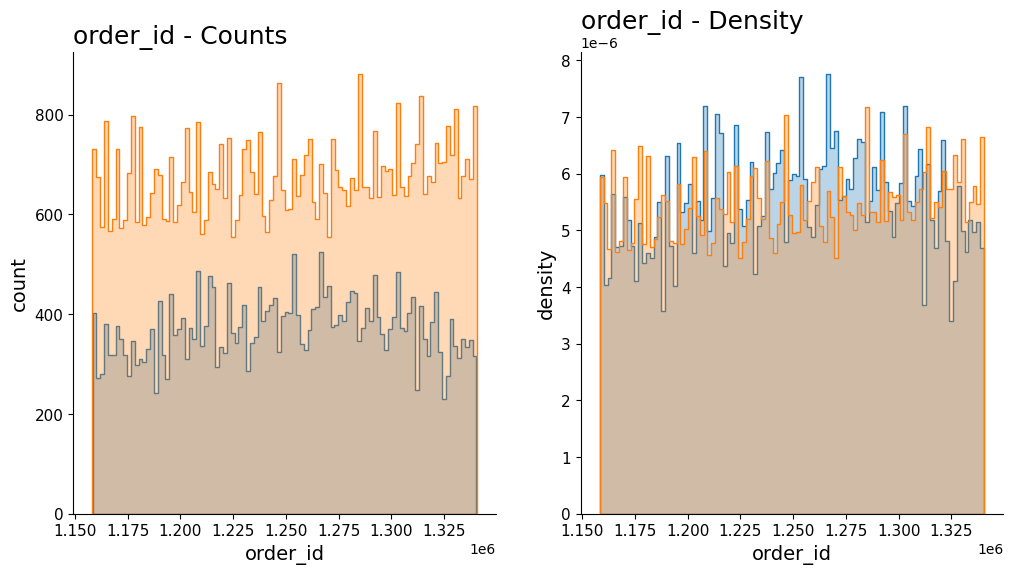

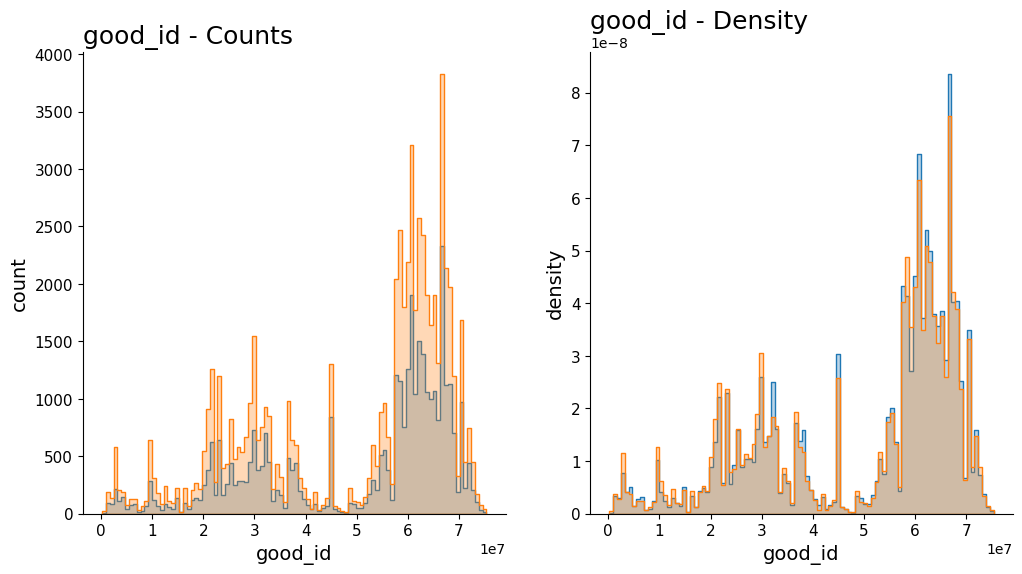

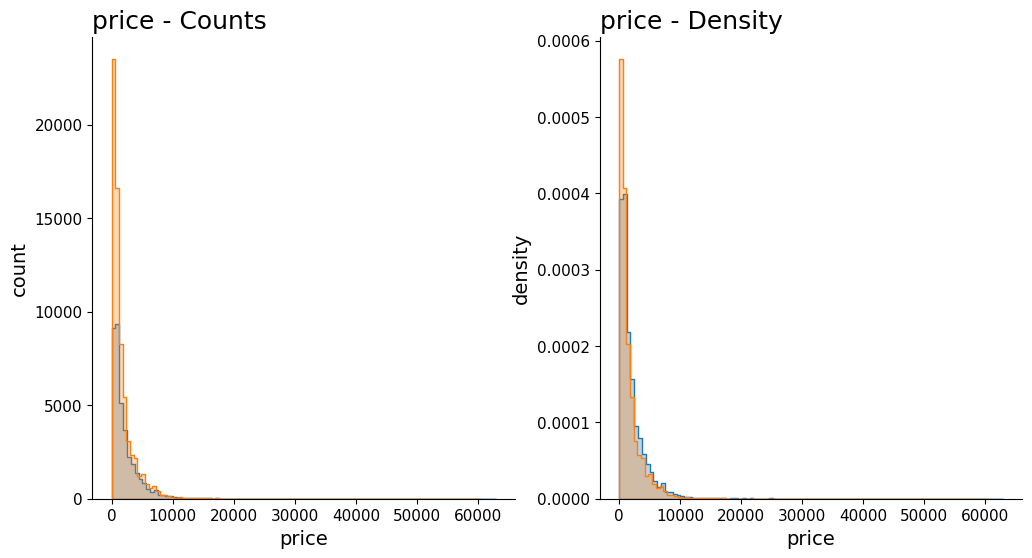

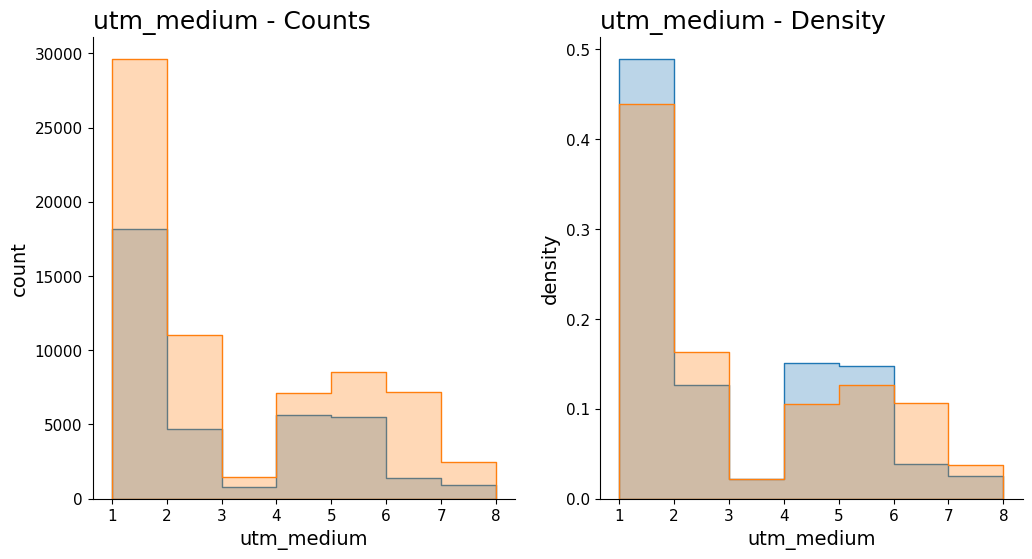

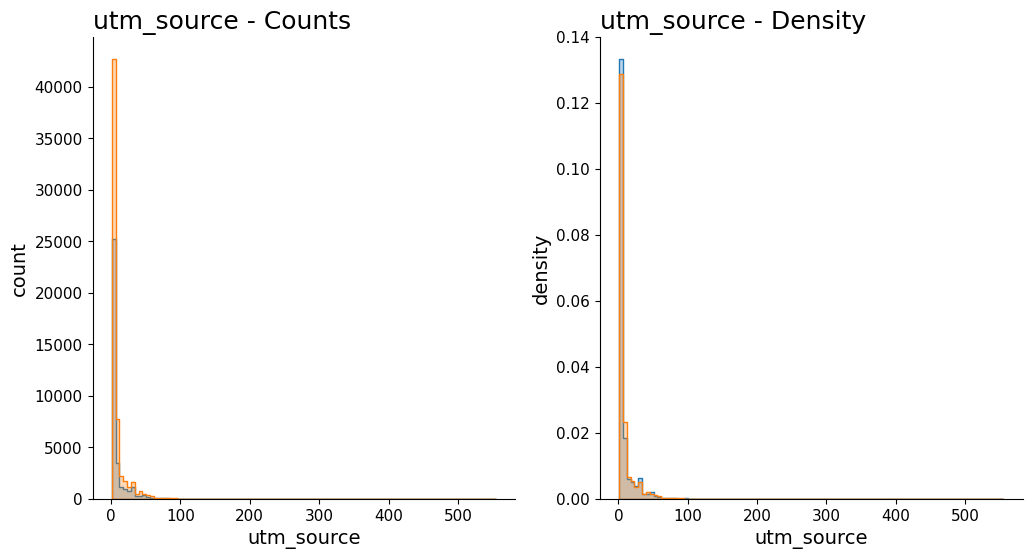

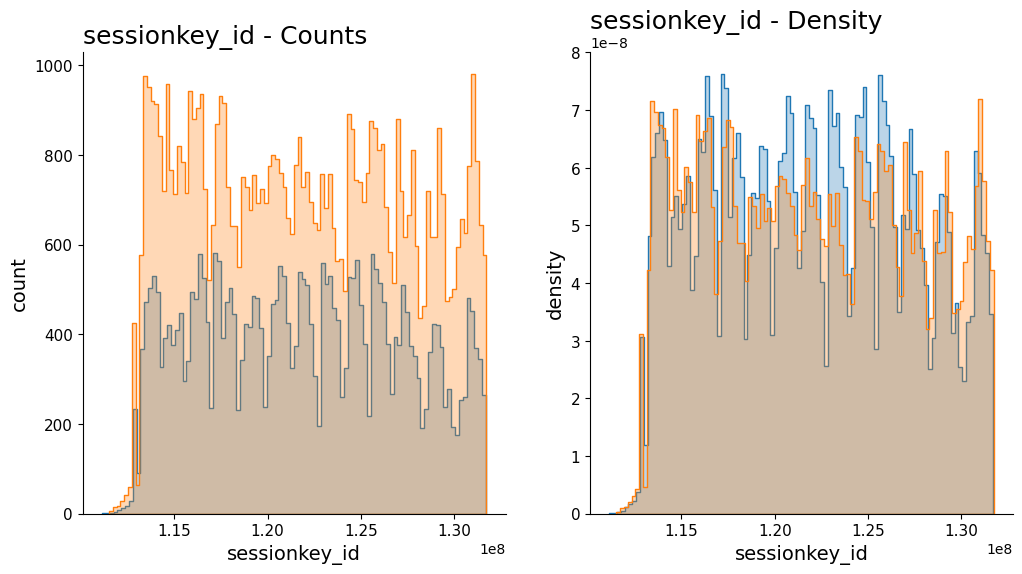

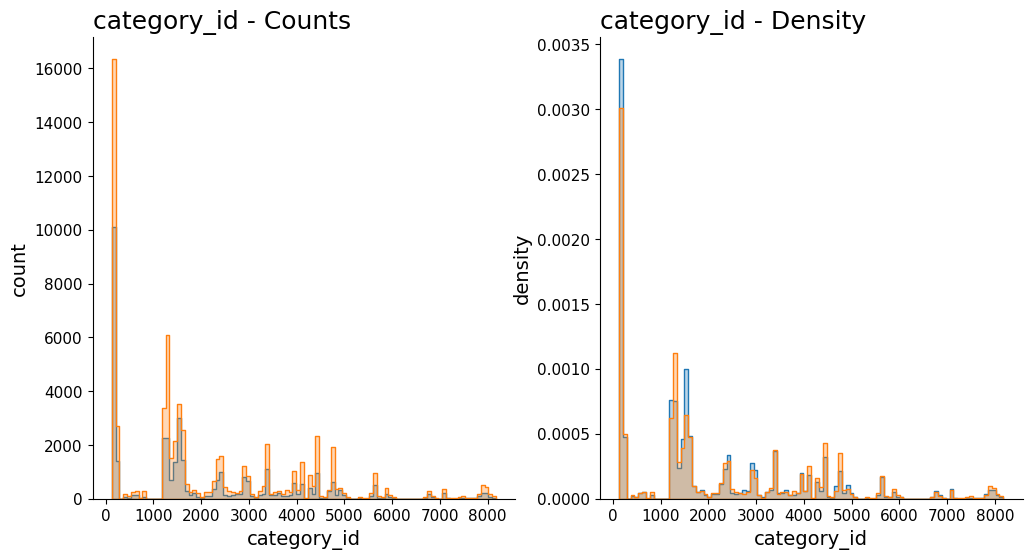

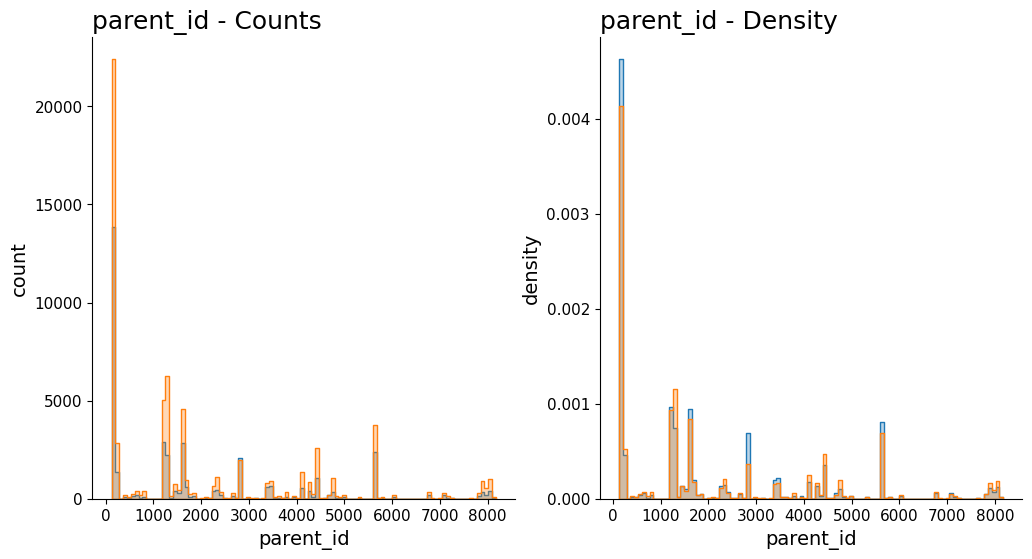

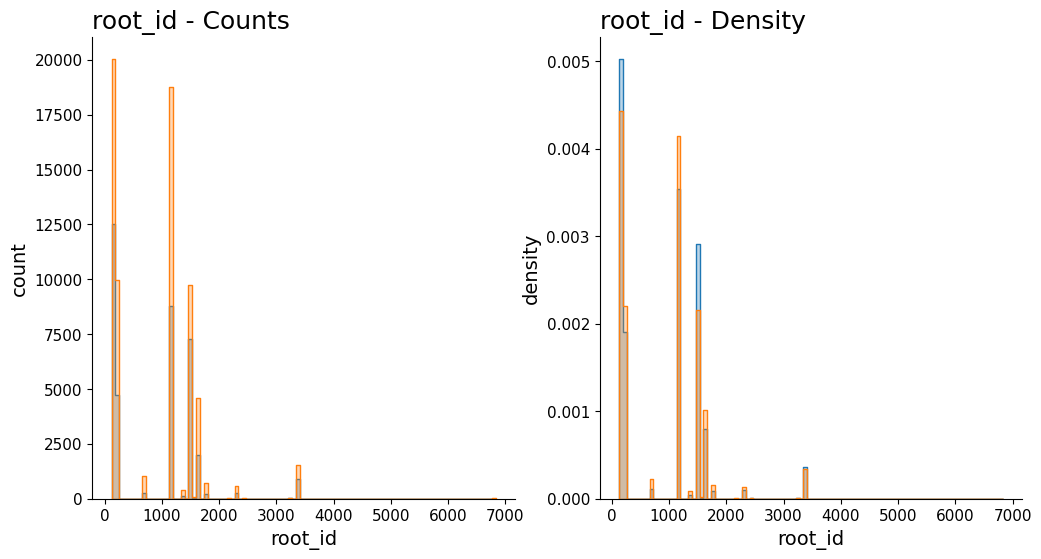

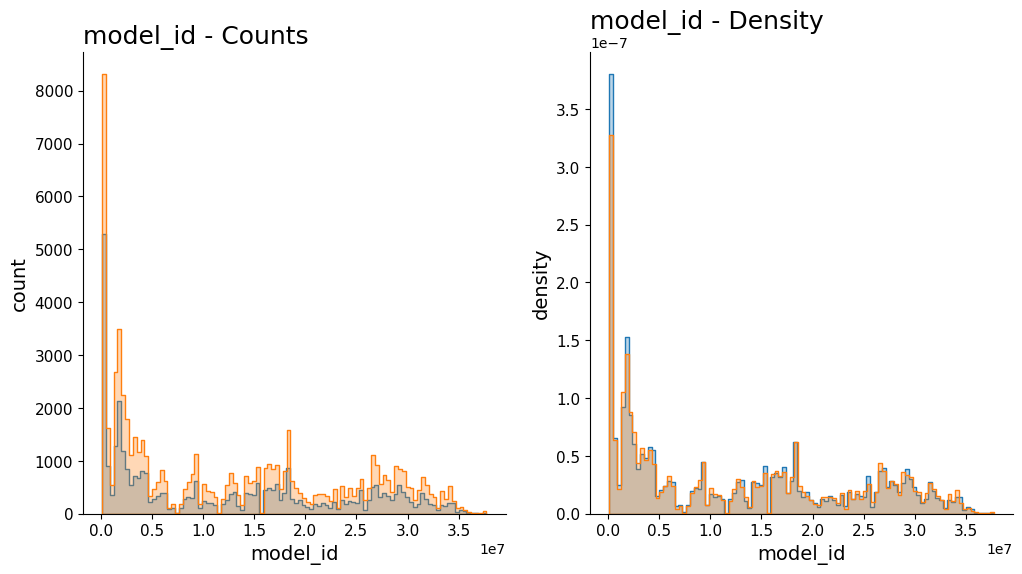

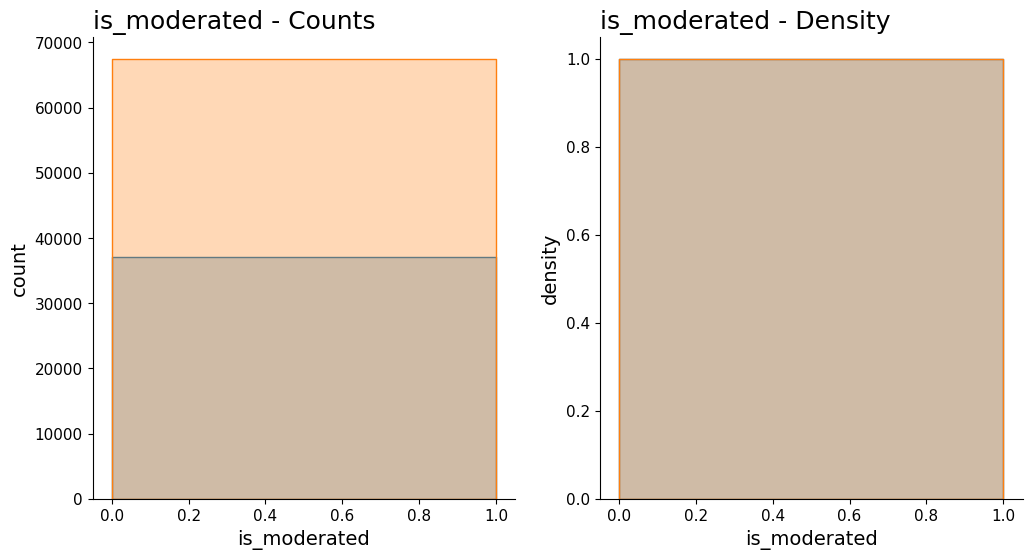

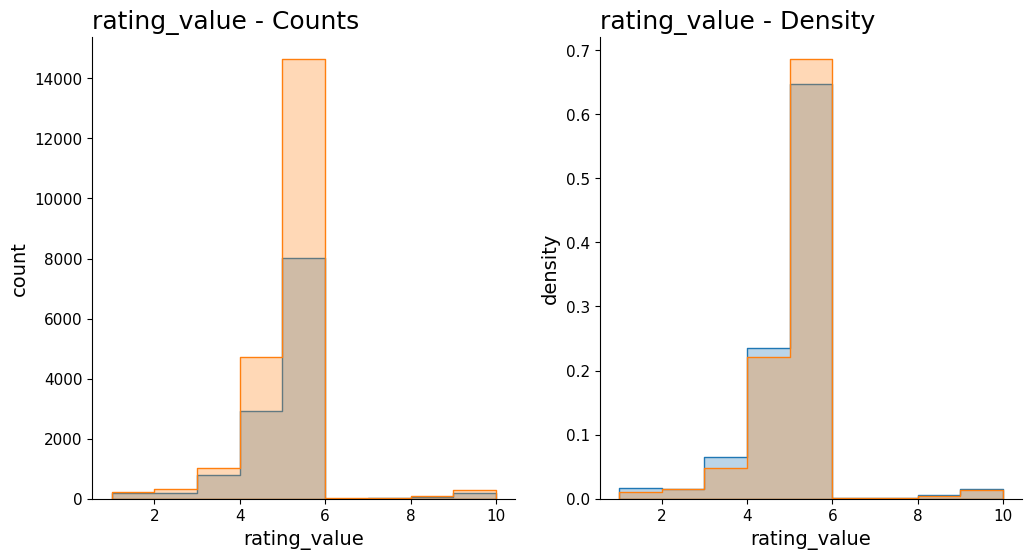

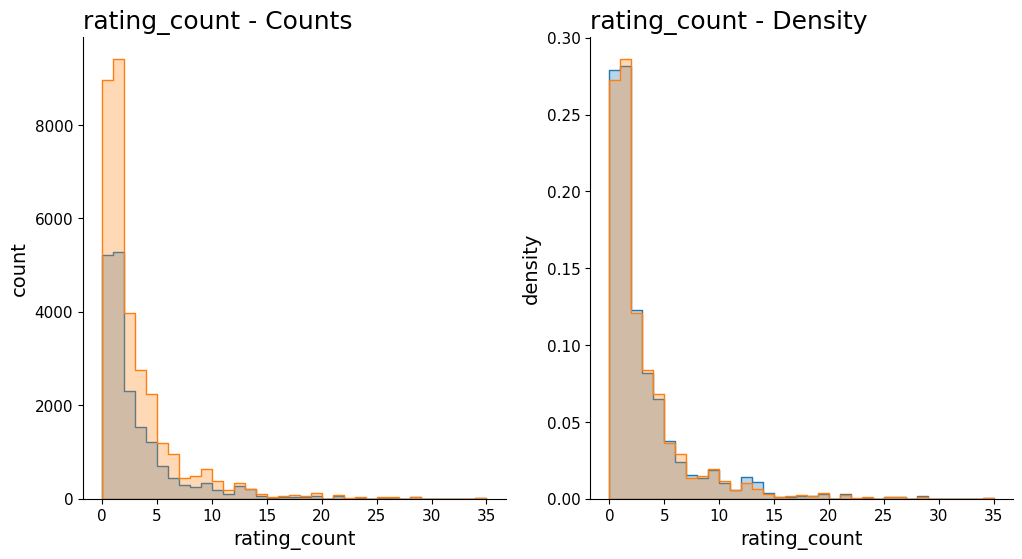

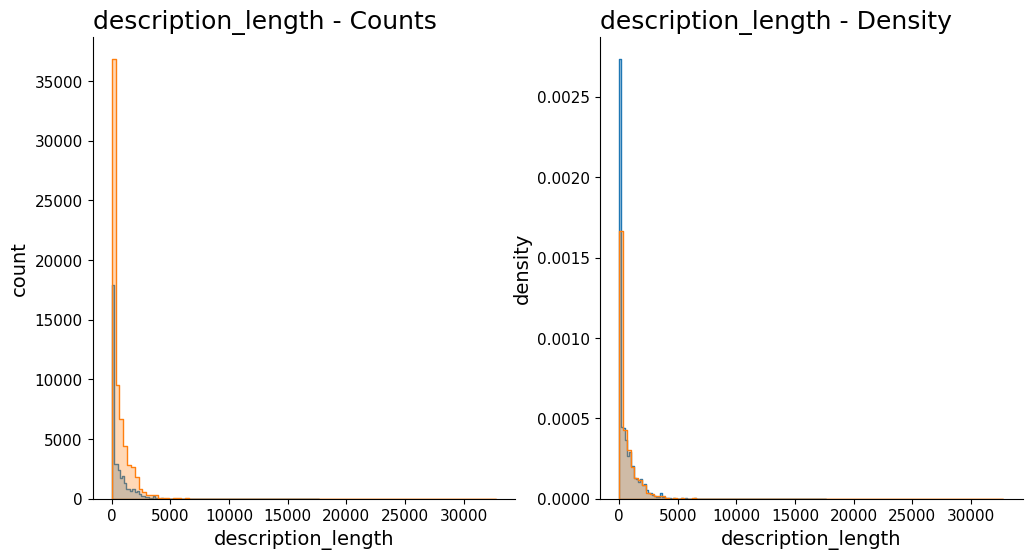

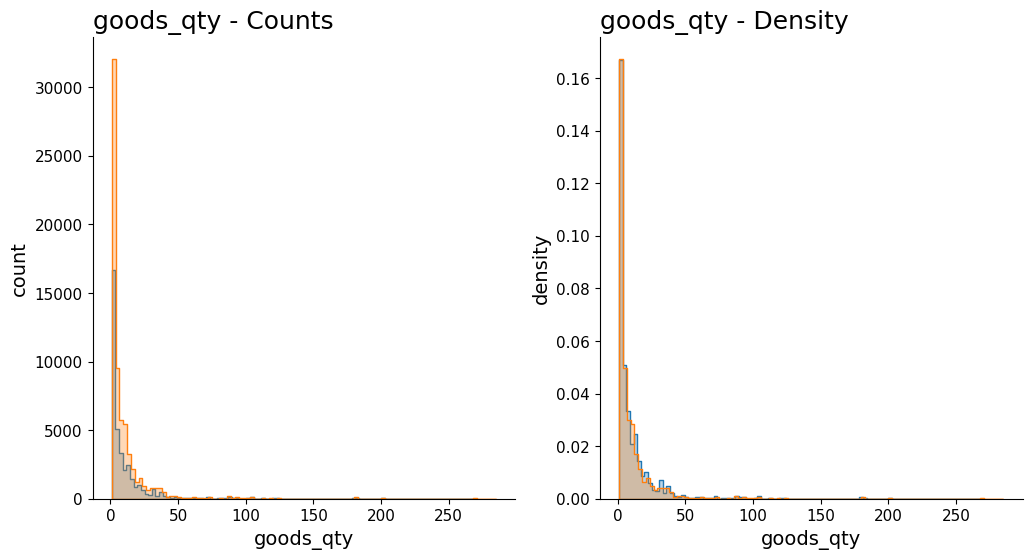

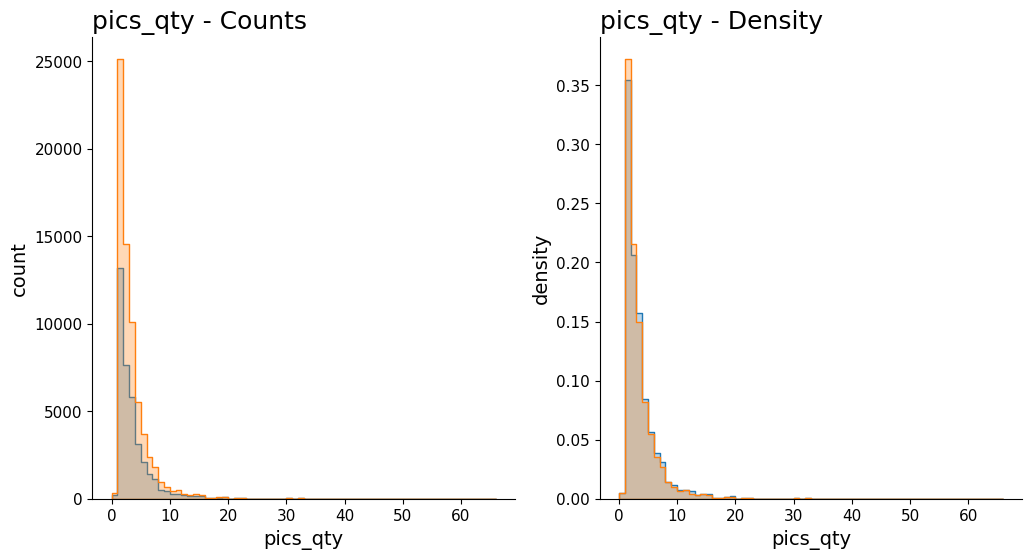

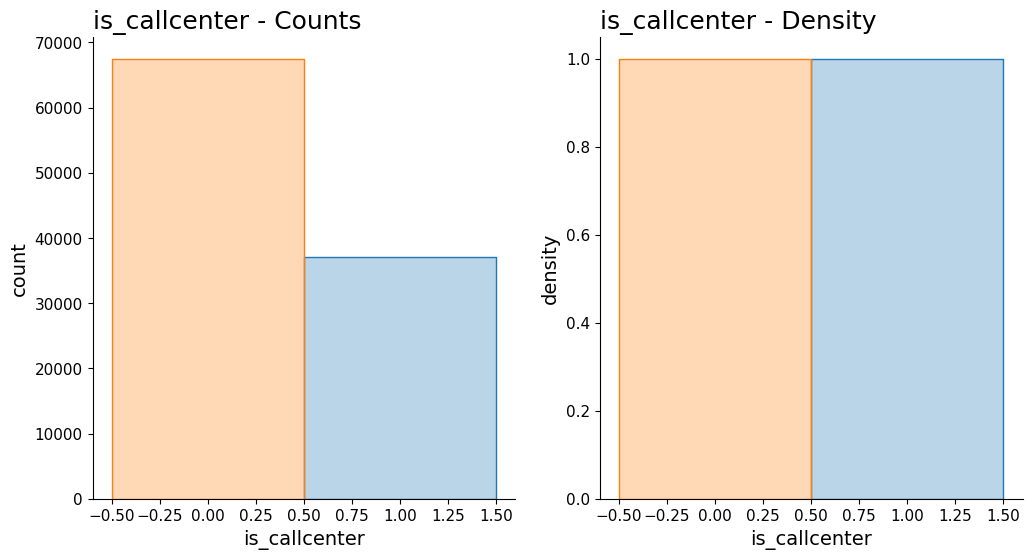

In [ ]:
# "можно решить без ML" - окпон, значит смотрим на гистограммы всего что можно и чего нельзя
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')


for col in df.columns:
    if df[col].dtype == float or df[col].dtype == int:
        f, axes = plt.subplots(1, 2, figsize = (12, 6))


        sns.histplot(df[(df.is_callcenter == 1)][col], alpha=0.3,  bins = min(100, int(df[col].max() - df[col].min())), element="step", ax = axes[0])
        sns.histplot(df[(df.is_callcenter == 0)][col], alpha=0.3,  bins = min(100, int(df[col].max() - df[col].min())), element="step", ax = axes[0])
        sns.despine()
        axes[0].set_title(f'{col} - Counts', fontsize=18, loc = 'left')
        axes[0].tick_params(axis='both', labelsize=11)
        axes[0].legend(fontsize=15)
        axes[0].get_legend().remove()
        axes[0].set_xlabel(f'{col}', size = 14)
        axes[0].set_ylabel('count', size = 14)


        sns.histplot(df[(df.is_callcenter == 1)][col], alpha=0.3,  bins = min(100, int(df[col].max() - df[col].min())), element="step", stat = 'density', ax = axes[1])
        sns.histplot(df[(df.is_callcenter == 0)][col], alpha=0.3,  bins = min(100, int(df[col].max() - df[col].min())), element="step", stat = 'density', ax = axes[1])
        sns.despine()
        axes[1].set_title(f'{col} - Density', fontsize=18, loc = 'left')
        axes[1].tick_params(axis='both', labelsize=11)
        axes[1].legend(fontsize=15)
        axes[1].get_legend().remove()
        axes[1].set_xlabel(f'{col}', size = 14)
        axes[1].set_ylabel('density', size = 14)
        plt.show


In [10]:
# эксперимент, очевидно, неудачный

Давайте поищем какие-нибудб паттерны в данных

Рисую две картинки: распределение в `counts` и `density`. У нас дисбаланс классов в соотношении примерно `class0 : class1 = 2:1`. Зачем два графика? По графику `counts` мы делаем таокй вывод: <i>из всех людей со значем признака feature = value, a человек звонят, а b человек - нет</i>. Если мы видим сильный дисбаланс между a и b (или вообще видим какой-то паттерн), то мы можем думать так: a>>b при значении feature = value, тогда если встретим человека со значением feature = value, то он скорее всего нам позвонит. То есть мысль идет от feature к target

А если смотреть на `density`, мы можем сравнивать <i>доли людей</i>, которые звонят или не звонят при таком значении признака среди всех людей нашей группы. Вывод будет примерно такой: доля людей, позвонивших нам и имеющих значение feature = value, сильно выше, чем доля людей с таким же значем, но не позвонивших нам. это мысль скорее target -> feature

Теперь посмотрим гистограммы всех графиков. Мы можем как-то использовать фичу, если мы видим хорошее разделение распределений групп по таргету на гистограммах.


обсудим все по порядку :)

* `order_id` - здесь довольно грубая гистограмма, возможно не очень подходящая под нашим данные. Но все-таки мы видим, что форма оранжевая (не звонили) более равномерная, а на голубой (есть звонок) мы наблюдаем такой купл в районе заказов 1200000 - 1275000. НО! id заказа имеет такой временной смысл. мы отдельно его посмотрим, когда будем заниматься временами session
* `good_id` - здесь тоже юзать гистограмму довольно глупо. Тут либо надо искать индивидуальные товары, которые как-то вызывают проблемы, либо вовсе не использовать
* `price` - в общем, мы видим, что разницы нет (см `Counts` - +- равное число людей звонят и не звонят). А вот в `Density` видны различия: звонки чуть больше характерны для дорогих товаров, чем дешевыз
* `utm_median` - мы видим различия в `Density`, но в `Counts` это не отражается
* `utm_score` - без различий
* `sessionkey_id` - аналогично `order_id`! Скорее всего в них тоже "зашита" временная составляющая, потому видим разницу распределений. Поробнее изучаем инфу про `sessionkey_id` при загрузке df sessions
* `category_id`, `parent_id`, `root_id` - в целом без различий, мб есть категории, которые просто слегка выбиваются
* `rating_counts, rating_values` - на удивление - тоже не помогают нам в разделении

Какой вывод по базовым признакам в `train.csv`? Они, грубо говоря, бесполезны. Все, кроме... `utm_medium`

Я использовала OHE для дискретных признаков с небольшим количеством значений (`page_type` в t1-webtat.csv и `utm_medium` в train.csv). Он вынесен отдельно

In [ ]:
# переводим в datetime

df['create_time'] = pd.to_datetime(df['create_time'])

Базовым минимумом мне показалось проверить, что заказы и сесси нумеруются по времени их создания.

Text(0, 0.5, 'order_id')

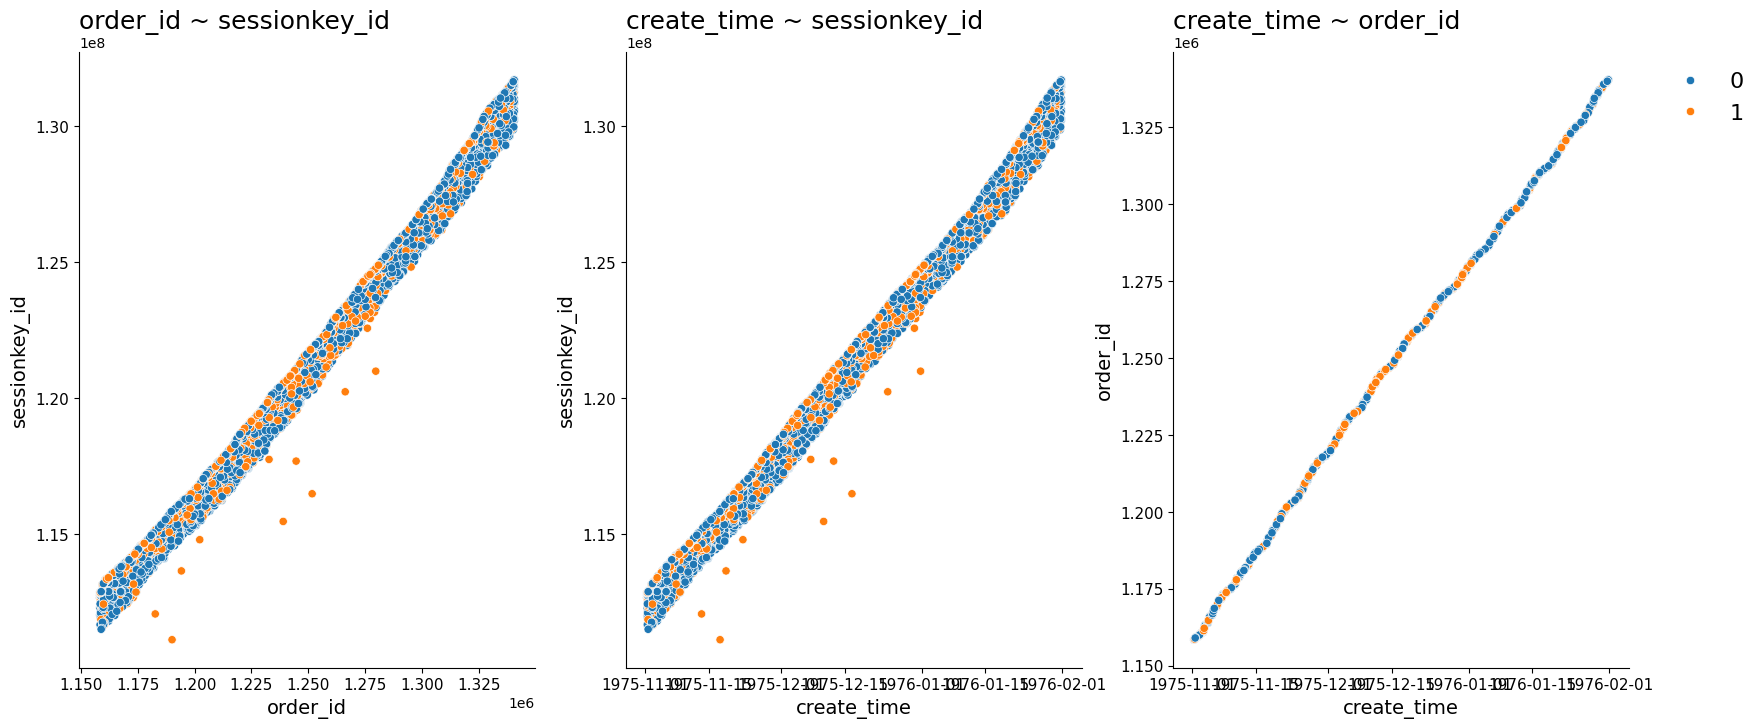

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (20, 8))

sns.scatterplot(data = df, x = 'order_id', y = 'sessionkey_id', hue = 'is_callcenter', ax = axes[0])
sns.despine()
axes[0].set_title(f'order_id ~ sessionkey_id', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel('order_id', size = 14)
axes[0].set_ylabel('sessionkey_id', size = 14)


sns.scatterplot(data = df, x = 'create_time', y = 'sessionkey_id', hue = 'is_callcenter', ax = axes[1])
sns.despine()
axes[1].set_title(f'create_time ~ sessionkey_id', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel('create_time', size = 14)
axes[1].set_ylabel('sessionkey_id', size = 14)


sns.scatterplot(data = df, x = 'create_time', y = 'order_id', hue = 'is_callcenter', ax = axes[2])
sns.despine()
axes[2].set_title(f'create_time ~ order_id', fontsize=18, loc = 'left')
axes[2].tick_params(axis='both', labelsize=11)
axes[2].legend(fontsize=15)
axes[2].legend(loc='upper left', bbox_to_anchor=(1.04, 1), fontsize = 16, frameon = False)
axes[2].set_xlabel('create_time', size = 14)
axes[2].set_ylabel('order_id', size = 14)

#### ВЫВОД ПО `train.csv`

Никакие (за исключением `utm_medium`) признаки из `train.csv` НЕ могут нам помочь в решении задачи.
Прогоним LogRegr на чистом train.csv для того, чтобы а) в этом удостовреиться; б) иметь бейслайн

In [915]:
# на всякий случай! обучим регрессию
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

prep = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

X, y = df.drop(['is_callcenter', 'create_time', 'model_create_time'], axis = 1), df['is_callcenter']
X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train = prep.fit_transform(X_train)
X_test = prep.transform(X_test)

clf = LogisticRegression()
clf.fit(X_train, y_train)
roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

0.5756173731585474

In [ ]:
# ну типа рокаук 0.5 - это угадывание) так что наша модель на traain.csv ничо не умеет
idx = np.argsort(-np.abs(clf.coef_))
df.drop(['is_callcenter', 'create_time', 'model_create_time'], axis = 1).columns.values[idx]

array([['sessionkey_id', 'order_id', 'price', 'utm_medium',
        'category_id', 'good_id', 'rating_value', 'model_id', 'pics_qty',
        'is_moderated', 'goods_qty', 'root_id', 'description_length',
        'rating_count', 'utm_source', 'parent_id']], dtype=object)

В общем, оставим `train.csv` и переходим к `t1-webstat.csv` - называю его сессии = sessions

## Переходим к сессиям 

In [917]:
# скачиваем
sessions = pd.read_csv('t1_webstat.csv')
print(f'shape = {sessions.shape}')
sessions.head(5)

shape = (3334243, 10)


,sessionkey_id,date_time,page_type,pageview_number,pageview_duration_sec,category_id,model_id,good_id,price,product_in_sale
0,122243978,1975-12-18 14:52:38.130,2,28,53.0,1773.0,NaN,NaN,NaN,NaN
1,122243978,1975-12-18 15:02:32.403,5,36,163.0,NaN,NaN,NaN,NaN,NaN
2,122243978,1975-12-18 15:08:11.147,5,40,156.0,NaN,NaN,NaN,NaN,NaN
3,122243992,1975-12-18 14:23:33.177,1,4,565.0,3973.0,26706175.0,45171119.0,8436.0,1.0
4,122243992,1975-12-18 14:32:58.763,1,5,73.0,3973.0,17297250.0,65195750.0,6624.0,1.0


In [ ]:
# проверяю, чем отличаются разные записи внутри одной и той же сессии

df[df['sessionkey_id'] == 122243978]

,order_id,create_time,good_id,price,utm_medium,utm_source,sessionkey_id,category_id,parent_id,root_id,...,is_moderated,rating_value,rating_count,description_length,goods_qty,pics_qty,model_create_time,is_callcenter,utm_medium_is_6,utm_medium_is_8
29863,1256221,1975-12-18 15:11:03,57791307,952,2,NaN,122243978,1496,3452,1493,...,1,5.0,2.0,991,10,2,1973-01-19 12:35:51.000,1,False,False
72292,1256220,1975-12-18 15:11:01,27249786,99,2,NaN,122243978,3552,3452,1493,...,0,NaN,NaN,93,1,1,1975-01-09 02:26:24.000,1,False,False


In [918]:
# добавим фичу model_ids - сколько их юзали

colnames = ['model_id_num']
sessions['model_id_num'] = sessions.groupby('sessionkey_id').model_id.transform('nunique')

sessions['model_id_num'].head(5)

0    6
1    6
2    6
3    3
4    3
Name: model_id_num, dtype: int64

In [919]:
# встречался среди них nan или нет

colnames.append('has_nan_mosel_id')
nan_sessions = sessions[sessions['model_id'].isna()].sessionkey_id.unique()

sessions['has_nan_mosel_id'] = [x in nan_sessions for x in sessions['sessionkey_id']]

In [920]:
# посчитаем общее время просмотра страниц в секундах
colnames.append('total_pageview_sec')

sessions['total_pageview_sec'] = sessions.groupby('sessionkey_id')['pageview_duration_sec'].transform('sum')
sessions['total_pageview_sec'].head()

0    3032.0
1    3032.0
2    3032.0
3     964.0
4     964.0
Name: total_pageview_sec, dtype: float64

In [921]:
# максимальный номер страницы по порядку из рассмотренных
colnames.append('max_pageview_order')

sessions['max_pageview_order'] = sessions.groupby('sessionkey_id')['pageview_number'].transform('max')
sessions['max_pageview_order'].head()

0    41
1    41
2    41
3     8
4     8
Name: max_pageview_order, dtype: int64

In [922]:
# посмотрим, сколько всего страниц было посмотрено (сколько разных по номеру страниц внутри сессии)
colnames.append('total_pages_viewed')

sessions['total_pages_viewed'] = sessions.groupby('sessionkey_id')['pageview_number'].transform('nunique')
sessions['total_pages_viewed'].head()

0    41
1    41
2    41
3     8
4     8
Name: total_pages_viewed, dtype: int64

In [923]:
# совпадает ли инфа о максимальной странице и общем колве страниц (есть ли пропуски в номерах страниц??) 1 = есть пропуски, 0 - нет пропусков
colnames.append('absent_pages')

sessions['absent_pages'] = sessions['max_pageview_order'] != sessions['total_pages_viewed']

In [924]:
# из них выведем среднее (в секундах) время просмотра одной страницы
colnames.append('mean_pageview_dur')


sessions['mean_pageview_dur'] = sessions['total_pageview_sec'] / sessions['total_pages_viewed']
sessions['mean_pageview_dur'].head()

0     73.95122
1     73.95122
2     73.95122
3    120.50000
4    120.50000
Name: mean_pageview_dur, dtype: float64

In [925]:
# сколько "висела" самая длинная страница
colnames.append('max_pageview_duration')

sessions['max_pageview_duration'] = sessions.groupby('sessionkey_id')['pageview_duration_sec'].transform('max')
sessions['max_pageview_duration'].head()

0    424.0
1    424.0
2    424.0
3    565.0
4    565.0
Name: max_pageview_duration, dtype: float64

In [926]:
# сколько длилась самая первая (загрузка?) и самая последняя (оплата?) страницы сессиии
colnames.append('first_pageview_duration')
colnames.append('last_pageview_duration')


last_view = sessions.loc[sessions.groupby('sessionkey_id')['pageview_number'].idxmax()][['sessionkey_id', 'pageview_duration_sec']].set_index('sessionkey_id').to_dict()
first_view = sessions.loc[sessions.groupby('sessionkey_id')['pageview_number'].idxmin()][['sessionkey_id', 'pageview_duration_sec']].set_index('sessionkey_id').to_dict()

sessions['first_pageview_duration'] = [first_view['pageview_duration_sec'][x] for x in sessions['sessionkey_id']]
sessions['last_pageview_duration'] = [last_view['pageview_duration_sec'][x] for x in sessions['sessionkey_id']]

In [927]:
sessions.head()

,sessionkey_id,date_time,page_type,pageview_number,pageview_duration_sec,category_id,model_id,good_id,price,product_in_sale,model_id_num,has_nan_mosel_id,total_pageview_sec,max_pageview_order,total_pages_viewed,absent_pages,mean_pageview_dur,max_pageview_duration,first_pageview_duration,last_pageview_duration
0,122243978,1975-12-18 14:52:38.130,2,28,53.0,1773.0,NaN,NaN,NaN,NaN,6,True,3032.0,41,41,False,73.95122,424.0,50.0,NaN
1,122243978,1975-12-18 15:02:32.403,5,36,163.0,NaN,NaN,NaN,NaN,NaN,6,True,3032.0,41,41,False,73.95122,424.0,50.0,NaN
2,122243978,1975-12-18 15:08:11.147,5,40,156.0,NaN,NaN,NaN,NaN,NaN,6,True,3032.0,41,41,False,73.95122,424.0,50.0,NaN
3,122243992,1975-12-18 14:23:33.177,1,4,565.0,3973.0,26706175.0,45171119.0,8436.0,1.0,3,True,964.0,8,8,False,120.50000,565.0,47.0,NaN
4,122243992,1975-12-18 14:32:58.763,1,5,73.0,3973.0,17297250.0,65195750.0,6624.0,1.0,3,True,964.0,8,8,False,120.50000,565.0,47.0,NaN


In [928]:
sessions['page_types'] = sessions.groupby('sessionkey_id')['page_type'].transform(lambda x: ' '.join(str(t) for t in x.unique()))

In [929]:
for pagetype in range(1,14):
    sessions[f'visited_{pagetype}_pagetype'] = sessions.page_types.str.contains(str(pagetype))
    colnames.append(f'visited_{pagetype}_pagetype')

sessions['visited_pagetype_number'] = [len(str(x).split()) for x in sessions['page_types']]
colnames.append('visited_pagetype_number')

sessions = sessions.drop('page_types', axis = 1)

In [930]:
# start page time
colnames.append('first_page_time')
colnames.append('last_page_time')


first_page_time = sessions.loc[sessions.groupby('sessionkey_id')['pageview_number'].idxmin()][['sessionkey_id', 'date_time']].set_index('sessionkey_id').to_dict()
last_page_time = sessions.loc[sessions.groupby('sessionkey_id')['pageview_number'].idxmax()][['sessionkey_id', 'date_time']].set_index('sessionkey_id').to_dict()

sessions['first_page_time'] = [first_page_time['date_time'][x] for x in sessions['sessionkey_id']]
sessions['last_page_time'] = [last_page_time['date_time'][x] for x in sessions['sessionkey_id']]
sessions['first_page_time'] = pd.to_datetime(sessions['first_page_time'])
sessions['last_page_time'] = pd.to_datetime(sessions['last_page_time'])
sessions.head()

,sessionkey_id,date_time,page_type,pageview_number,pageview_duration_sec,category_id,model_id,good_id,price,product_in_sale,...,visited_7_pagetype,visited_8_pagetype,visited_9_pagetype,visited_10_pagetype,visited_11_pagetype,visited_12_pagetype,visited_13_pagetype,visited_pagetype_number,first_page_time,last_page_time
0,122243978,1975-12-18 14:52:38.130,2,28,53.0,1773.0,NaN,NaN,NaN,NaN,...,False,True,True,False,False,False,False,5,1975-12-18 14:20:15.210,1975-12-18 15:10:47.973
1,122243978,1975-12-18 15:02:32.403,5,36,163.0,NaN,NaN,NaN,NaN,NaN,...,False,True,True,False,False,False,False,5,1975-12-18 14:20:15.210,1975-12-18 15:10:47.973
2,122243978,1975-12-18 15:08:11.147,5,40,156.0,NaN,NaN,NaN,NaN,NaN,...,False,True,True,False,False,False,False,5,1975-12-18 14:20:15.210,1975-12-18 15:10:47.973
3,122243992,1975-12-18 14:23:33.177,1,4,565.0,3973.0,26706175.0,45171119.0,8436.0,1.0,...,True,True,False,False,False,False,False,4,1975-12-18 14:20:18.877,1975-12-18 14:36:22.503
4,122243992,1975-12-18 14:32:58.763,1,5,73.0,3973.0,17297250.0,65195750.0,6624.0,1.0,...,True,True,False,False,False,False,False,4,1975-12-18 14:20:18.877,1975-12-18 14:36:22.503


In [931]:
# не общее время просмотра страниц, а разница timestamp-ов в секундах
colnames.append('total_session_time')

sessions['total_session_time'] = (sessions['last_page_time'] - sessions['first_page_time']).dt.total_seconds()
sessions['total_session_time'].head()

0    3032.763
1    3032.763
2    3032.763
3     963.626
4     963.626
Name: total_session_time, dtype: float64

In [932]:
sessions.columns

Index(['sessionkey_id', 'date_time', 'page_type', 'pageview_number',
       'pageview_duration_sec', 'category_id', 'model_id', 'good_id', 'price',
       'product_in_sale', 'model_id_num', 'has_nan_mosel_id',
       'total_pageview_sec', 'max_pageview_order', 'total_pages_viewed',
       'absent_pages', 'mean_pageview_dur', 'max_pageview_duration',
       'first_pageview_duration', 'last_pageview_duration',
       'visited_1_pagetype', 'visited_2_pagetype', 'visited_3_pagetype',
       'visited_4_pagetype', 'visited_5_pagetype', 'visited_6_pagetype',
       'visited_7_pagetype', 'visited_8_pagetype', 'visited_9_pagetype',
       'visited_10_pagetype', 'visited_11_pagetype', 'visited_12_pagetype',
       'visited_13_pagetype', 'visited_pagetype_number', 'first_page_time',
       'last_page_time', 'total_session_time'],
      dtype='object')

In [933]:
# колво категорий
colnames.append('categories_viewed')

sessions['categories_viewed'] = sessions.groupby('sessionkey_id').category_id.transform('nunique')

In [934]:
# колво товаров
colnames.append('goods_viewed')

sessions['goods_viewed'] = sessions.groupby('sessionkey_id').good_id.transform('nunique')

In [935]:
colnames.append('frac_cat')
colnames.append('frac_good')



sessions['frac_cat'] = sessions['categories_viewed'] / sessions['total_pages_viewed']
sessions['frac_good'] = sessions['goods_viewed'] / sessions['total_pages_viewed']

In [936]:
# if we have negative pageview_duration_sec
colnames.append('has_negative_pageview_dur')

sessions['has_negative_pageview_dur'] = sessions.groupby('sessionkey_id').pageview_duration_sec.transform('min') < 0

In [937]:
# потом посмотрим купили товар кторый просматривали или нет
colnames.append('good_ids')

sessions['good_ids'] = sessions.groupby('sessionkey_id')['good_id'].transform(lambda x: ' '.join(str(t) for t in x.unique()))

In [938]:
colnames.append('sessionkey_id')

sessions_agg = sessions[colnames].drop_duplicates()
print(f'{sessions_agg.shape}')
sessions_agg.head()

(328430, 34)


,model_id_num,has_nan_mosel_id,total_pageview_sec,max_pageview_order,total_pages_viewed,absent_pages,mean_pageview_dur,max_pageview_duration,first_pageview_duration,last_pageview_duration,...,first_page_time,last_page_time,total_session_time,categories_viewed,goods_viewed,frac_cat,frac_good,has_negative_pageview_dur,good_ids,sessionkey_id
0,6,True,3032.0,41,41,False,73.95122,424.0,50.0,NaN,...,1975-12-18 14:20:15.210,1975-12-18 15:10:47.973,3032.763,6,6,0.146341,0.146341,False,nan 57791307.0 31028362.0 57791291.0 5864096.0...,122243978
3,3,True,964.0,8,8,False,120.50000,565.0,47.0,NaN,...,1975-12-18 14:20:18.877,1975-12-18 14:36:22.503,963.626,1,3,0.125000,0.375000,False,45171119.0 65195750.0 nan 45689192.0,122243992
5,2,True,150.0,5,5,False,30.00000,86.0,86.0,NaN,...,1975-12-18 14:20:20.760,1975-12-18 14:22:50.653,149.893,1,2,0.200000,0.400000,False,59718865.0 nan 4087157.0,122243998
6,1,True,62.0,2,2,False,31.00000,62.0,62.0,NaN,...,1975-12-18 14:20:53.793,1975-12-18 14:21:55.320,61.527,1,1,0.500000,0.500000,False,nan 29666875.0,122244115
8,6,True,1376.0,55,40,True,34.40000,173.0,3.0,NaN,...,1975-12-18 14:21:30.973,1975-12-18 15:05:37.350,2646.377,4,6,0.100000,0.150000,False,67362756.0 nan 62749615.0 3555301.0 67363046.0...,122244260


какие фичи считались в предыдущих ячейках? в принципе, все, что представляло из себя хоть какую то логическую ценность.

объяснение фичей написаны в соотв окошках


Теперь у нас есть `sessions_agg` - всевозможные признаки, посчитанные из `sessions`. Именно эти данные я буду мерджить с train и test.



* Я уверена, что большая часть из этих данных - мусорная. Например, побить первый бейслайн со скором типа 0.88 у меня получилось вообще на 3 фичах (оставила в самых послеждних ячейках). Но к сожалению выбирать из такого набора было слишком болезненно в ночь дедлайна, поэтому решение будет считаться на всех фичах сразу

In [ ]:
said_df = df.merge(sessions_agg, on = 'sessionkey_id', how = 'left', validate = 'm:m')

# смотрим новый shape и head
print(f'shape = {said_df.shape}')
said_df.head()

shape = (104595, 52)


,order_id,create_time,good_id,price,utm_medium,utm_source,sessionkey_id,category_id,parent_id,root_id,...,visited_pagetype_number,first_page_time,last_page_time,total_session_time,categories_viewed,goods_viewed,frac_cat,frac_good,has_negative_pageview_dur,good_ids
0,1269921,1975-12-26 09:30:08,9896348,753,5,8.0,123777004,139,133,124,...,1.0,1975-12-26 09:21:03.393,1975-12-26 09:21:03.393,0.000,1.0,1.0,1.000000,1.000000,False,9896348.0
1,1270034,1975-12-26 10:28:57,9896348,753,1,2.0,123781654,139,133,124,...,6.0,1975-12-26 09:50:26.857,1975-12-26 11:01:03.407,4236.550,2.0,8.0,0.071429,0.285714,False,67188222.0 nan 10223281.0 67308204.0 9896348.0...
2,1268272,1975-12-25 11:24:28,9896348,753,2,3.0,123591002,139,133,124,...,5.0,1975-12-25 11:17:02.940,1975-12-25 11:23:12.517,369.577,1.0,1.0,0.142857,0.142857,False,nan 9896348.0
3,1270544,1975-12-26 14:16:06,9896348,753,1,1.0,123832302,139,133,124,...,1.0,1975-12-26 13:57:51.157,1975-12-26 14:29:57.153,1925.996,3.0,0.0,0.500000,0.000000,False,nan
4,1270970,1975-12-26 18:21:47,9896348,753,3,56.0,123881603,139,133,124,...,4.0,1975-12-26 18:10:27.970,1975-12-26 18:17:54.257,446.287,1.0,1.0,0.166667,0.166667,False,nan 9896348.0


In [940]:
# еще одна фича - смотрели ли товар внутри сессии. типа если нет, то возможно звонили, чтобы о нем узнать

said_df['searched_good'] = [str(float(said_df['good_id'][i])) in said_df['good_ids'][i].split() if type(said_df['good_ids'][i]) == str else np.nan for i in range(said_df.shape[0])]
said_df = said_df.drop('good_ids', axis = 1)

#### Дискретные фичи

In [941]:
from collections import defaultdict as dd
calls = dd(int)
no_calls = dd(int)


for pagetype in range(1,14):
    calls[pagetype] = said_df[said_df['is_callcenter'] == 1][f'visited_{pagetype}_pagetype'].sum()
    no_calls[pagetype] = said_df[said_df['is_callcenter'] == 0][f'visited_{pagetype}_pagetype'].sum()
    print(f'pagetype = {pagetype}, fraction of class0 = {no_calls[pagetype] / (no_calls[pagetype] + calls[pagetype])}')


pagetype = 1, fraction of class0 = 0.6457188798070481
pagetype = 2, fraction of class0 = 0.6674962212009711
pagetype = 3, fraction of class0 = 0.8639582786872598
pagetype = 4, fraction of class0 = 0.7509597941188879
pagetype = 5, fraction of class0 = 0.74024002313476
pagetype = 6, fraction of class0 = 0.9680901825122271
pagetype = 7, fraction of class0 = 0.7121911283119976
pagetype = 8, fraction of class0 = 0.7603124498421701
pagetype = 9, fraction of class0 = 0.7299221058286328
pagetype = 10, fraction of class0 = 0.7184698147041243
pagetype = 11, fraction of class0 = 0.9318181818181818
pagetype = 12, fraction of class0 = 0.7475961538461539
pagetype = 13, fraction of class0 = 0.784375


Это супер-фича) Видно, что для `pagetype` = 6 доля НЕзвонивших людей 0.96, а для типа 11 - 0.93

Но сама по себе доля не очень информативна, поэтому ниже есть барплот

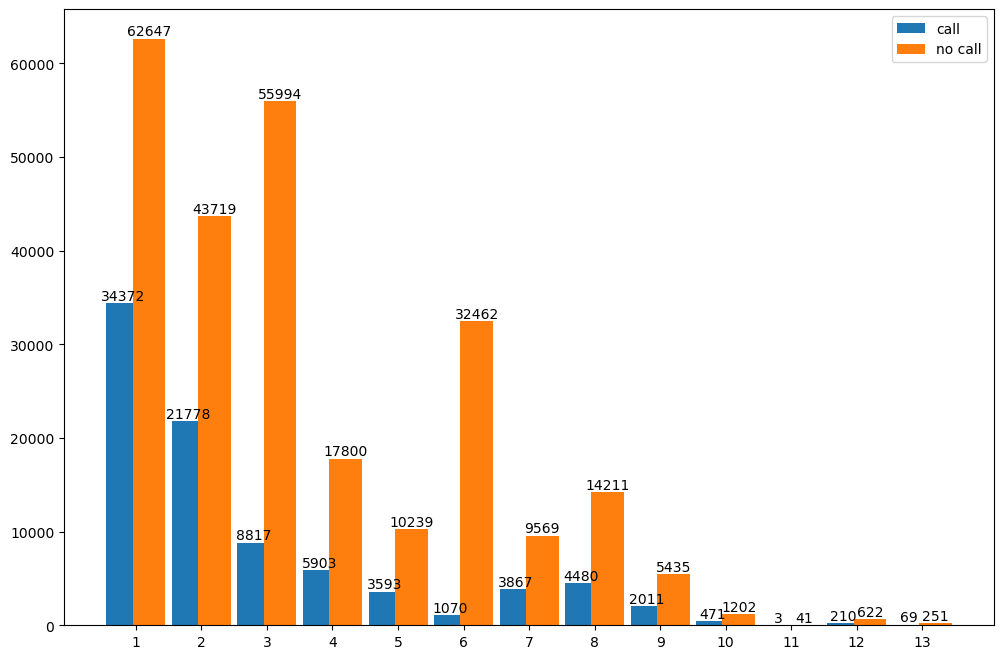

In [942]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize = (12,8))
a1 = ax.bar(np.arange(1,14) - 0.2, calls.values(), width=0.5, label='call')
ax.bar_label(a1, label_type='edge')

a2 = ax.bar(np.arange(1,14) + 0.2, no_calls.values(), width=0.5, label='no call')
ax.bar_label(a2, label_type='edge')

ax.set_xticks(np.arange(1,14))
ax.legend()

plt.show()

Ну прям видно, что для 3,6 pagetype сильный дисбаланс классов ловим

In [943]:
# аналогично дискретный признак utm_medium -- из оригинальной train.csv

from collections import defaultdict as dd
calls = dd(int)
no_calls = dd(int)

for utm in range(df.utm_medium.min(), df.utm_medium.max() + 1):
    calls[utm] = df[(df['is_callcenter'] == 1) & (df['utm_medium'] == utm)].shape[0]
    no_calls[utm] = df[(df['is_callcenter'] == 0) & (df['utm_medium'] == utm)].shape[0]
    print(f'utm_medium = {utm}, fraction of class0 = {no_calls[utm] / (no_calls[utm] + calls[utm])}')

utm_medium = 1, fraction of class0 = 0.6200317965023847
utm_medium = 2, fraction of class0 = 0.7024309532900598
utm_medium = 3, fraction of class0 = 0.6466960352422908
utm_medium = 4, fraction of class0 = 0.5590223200251493
utm_medium = 5, fraction of class0 = 0.6084135472370766
utm_medium = 6, fraction of class0 = 0.8354004868436304
utm_medium = 7, fraction of class0 = 0.7202643171806168
utm_medium = 8, fraction of class0 = 0.8221343873517787


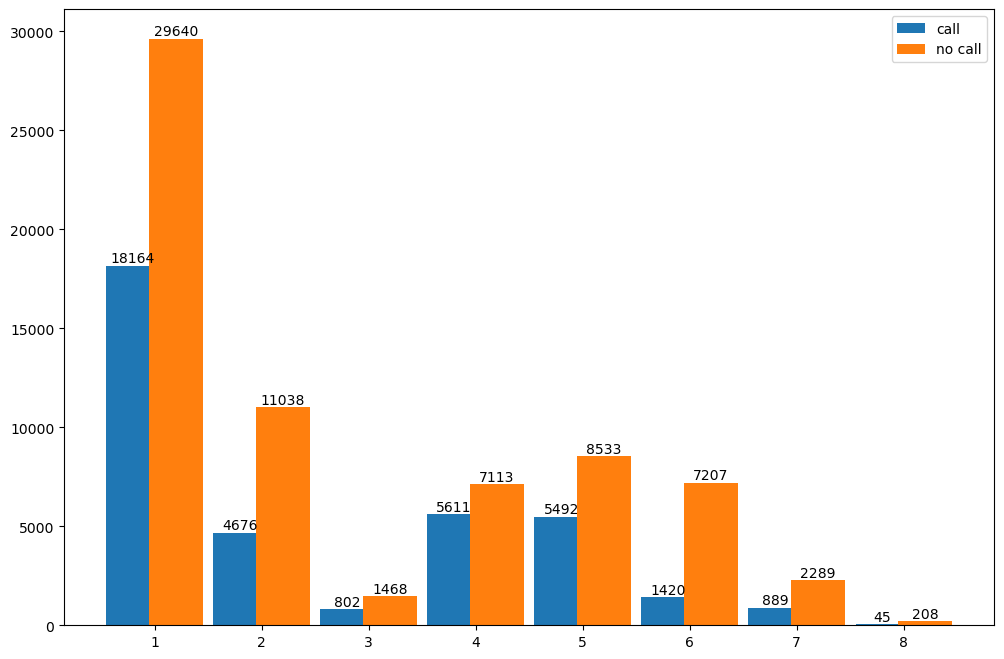

In [945]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize = (12,8))
a1 = ax.bar(np.arange(1,9) - 0.2, calls.values(), width=0.5, label='call')
ax.bar_label(a1, label_type='edge')

a2 = ax.bar(np.arange(1,9) + 0.2, no_calls.values(), width=0.5, label='no call')
ax.bar_label(a2, label_type='edge')

ax.set_xticks(np.arange(1,9))
ax.legend()

plt.show()

здесь нас тоже интересует 6 класс - дисбаланс!

#### создаем дополнительные временные и бинарные фичи

In [ ]:
# NAN-ов куча, поэтому я скорее всего вынесу их в отдельный классификатор

said_df['max_pageview_duration_isnan'] = said_df['max_pageview_duration'].isna()
said_df['last_pageview_duration_isnan'] = -said_df['last_pageview_duration'].isna()
said_df['first_pageview_duration_isnan'] = said_df['first_pageview_duration'].isna()

In [948]:
# это время от создания заказа до 1) начала тырканья по сайту 2) заходом на последнюю странцу

said_df['first_page_to_create_time'] = (said_df['create_time'] - said_df['first_page_time']).dt.total_seconds()
said_df['last_page_to_create_time'] = (said_df['create_time'] - said_df['last_page_time']).dt.total_seconds()

In [949]:
# для некоторых фичей есть отрицтельные значения

said_df['first_page_to_create_time_sign'] = said_df['first_page_to_create_time'] > 0
said_df['last_pageview_duration_sign'] = said_df['last_pageview_duration'] > 0

In [951]:
said_df['after_last_page'] = said_df['last_page_to_create_time'] - said_df['last_pageview_duration']
said_df['after_last_page_isna'] = said_df['after_last_page'].isna()

In [752]:
said_df['total_price'] = said_df.price * said_df.goods_qty

In [ ]:
#здесь для кадждого столбца проверяется распределение is_callcenter внутри отрицетльынх и положительных значений (если они есть)


import warnings
warnings.filterwarnings('ignore')

calls = dd(int)
no_calls = dd(int)

for col in said_df.drop('is_callcenter', axis = 1).columns:

    if col in ['create_time', 'model_create_time', 'first_page_time', 'last_page_time', 'page_types']:
        pass
    else:

        print(col)
        calls[col] = said_df[said_df[col]< 0][said_df['is_callcenter'] == 1].shape[0]
        no_calls[col] = said_df[said_df[col] < 0][said_df['is_callcenter'] == 0].shape[0]

        if calls[col] == 0 or no_calls[col] == 0:
            print(f'no negatives or one class: {no_calls[col]}, {calls[col]}')
        else:
            print(f'column = {col}, fraction of class0 when <0 = {no_calls[col] / (no_calls[col] + calls[col])}')

        calls[col] = said_df[said_df[col] >= 0][said_df['is_callcenter'] == 1].shape[0]
        no_calls[col] = said_df[said_df[col] >= 0][said_df['is_callcenter'] == 0].shape[0]
        if calls[col] == 0 or no_calls[col] == 0:
            print(f'no positives or one class: {no_calls[col]}, {calls[col]}')
        else:
            print(f'column = {col}, fraction of class0 when >= 0 = {no_calls[col] / (no_calls[col] + calls[col])}\n')

order_id
no negatives or one class: 0, 0
column = order_id, fraction of class0 when >= 0 = 0.6453080931210861

good_id
no negatives or one class: 0, 0
column = good_id, fraction of class0 when >= 0 = 0.6453080931210861

price
no negatives or one class: 0, 0
column = price, fraction of class0 when >= 0 = 0.6453080931210861

utm_medium
no negatives or one class: 0, 0
column = utm_medium, fraction of class0 when >= 0 = 0.6453080931210861

utm_source
no negatives or one class: 0, 0
column = utm_source, fraction of class0 when >= 0 = 0.6372085612618833

sessionkey_id
no negatives or one class: 0, 0
column = sessionkey_id, fraction of class0 when >= 0 = 0.6453080931210861

category_id
no negatives or one class: 0, 0
column = category_id, fraction of class0 when >= 0 = 0.6453080931210861

parent_id
no negatives or one class: 0, 0
column = parent_id, fraction of class0 when >= 0 = 0.6453080931210861

root_id
no negatives or one class: 0, 0
column = root_id, fraction of class0 when >= 0 = 0.645

In [952]:
#здесь для кадждого столбца проверяется распределение is_callcenter внутри NAN и остальных значений (если они есть)

calls = dd(int)
no_calls = dd(int)

for col in said_df.drop('is_callcenter', axis = 1).columns:

    calls[col] = said_df[said_df[col].isna()][said_df['is_callcenter'] == 1].shape[0]
    no_calls[col] = said_df[said_df[col].isna()][said_df['is_callcenter'] == 0].shape[0]

    if calls[col] == 0 or no_calls[col] == 0:
        print(f'no NANs or one class: {no_calls[col]}, {calls[col]}')
    else:
        print(f'column = {col}, fraction of class0 when NAN = {no_calls[col] / (no_calls[col] + calls[col])}')

    calls[col] = said_df[-said_df[col].isna()][said_df['is_callcenter'] == 1].shape[0]
    no_calls[col] = said_df[-said_df[col].isna()][said_df['is_callcenter'] == 0].shape[0]
    if calls[col] == 0 or no_calls[col] == 0:
        print(f'no NANs or one class: {no_calls[col]}, {calls[col]}')
    else:
        print(f'column = {col}, fraction of class0 when non-NAN = {no_calls[col] / (no_calls[col] + calls[col])}\n')




no NANs or one class: 0, 0
column = order_id, fraction of class0 when non-NAN = 0.6453080931210861

no NANs or one class: 0, 0
column = create_time, fraction of class0 when non-NAN = 0.6453080931210861

no NANs or one class: 0, 0
column = good_id, fraction of class0 when non-NAN = 0.6453080931210861

no NANs or one class: 0, 0
column = price, fraction of class0 when non-NAN = 0.6453080931210861

no NANs or one class: 0, 0
column = utm_medium, fraction of class0 when non-NAN = 0.6453080931210861

column = utm_source, fraction of class0 when NAN = 0.7182775119617225
column = utm_source, fraction of class0 when non-NAN = 0.6372085612618833

no NANs or one class: 0, 0
column = sessionkey_id, fraction of class0 when non-NAN = 0.6453080931210861

no NANs or one class: 0, 0
column = category_id, fraction of class0 when non-NAN = 0.6453080931210861

no NANs or one class: 0, 0
column = parent_id, fraction of class0 when non-NAN = 0.6453080931210861

no NANs or one class: 0, 0
column = root_id, 

Если посмотреть по NAN-ам, то мы видим, что распределение классов для `after_last_page` и `last_page_to_create_time` одинаково, то есть колонки `after_last_page_isna == last_page_to_create_time_isna`

Дропаю одну из них

In [953]:
said_df = said_df.drop('after_last_page_isna', axis = 1)

In [954]:
said_df['utm_medium_is_6'] = said_df['utm_medium'] == 6
said_df['utm_medium_is_8'] = said_df['utm_medium'] == 8

In [955]:
new_cols = set(said_df.columns) - set(df.columns)

#### ТУТ ОБЗОР НОВЫХ ФИЧЕЙ. много гистограмм

In [ ]:
# СМОТРИМ НА НОВЫЕ ФИЧИ!

In [768]:
said_df[['absent_pages', 'is_callcenter']].value_counts()

absent_pages  is_callcenter
True          0                44763
False         1                31994
              0                22479
True          1                 4735
Name: count, dtype: int64

Text(0, 0.5, 'density')

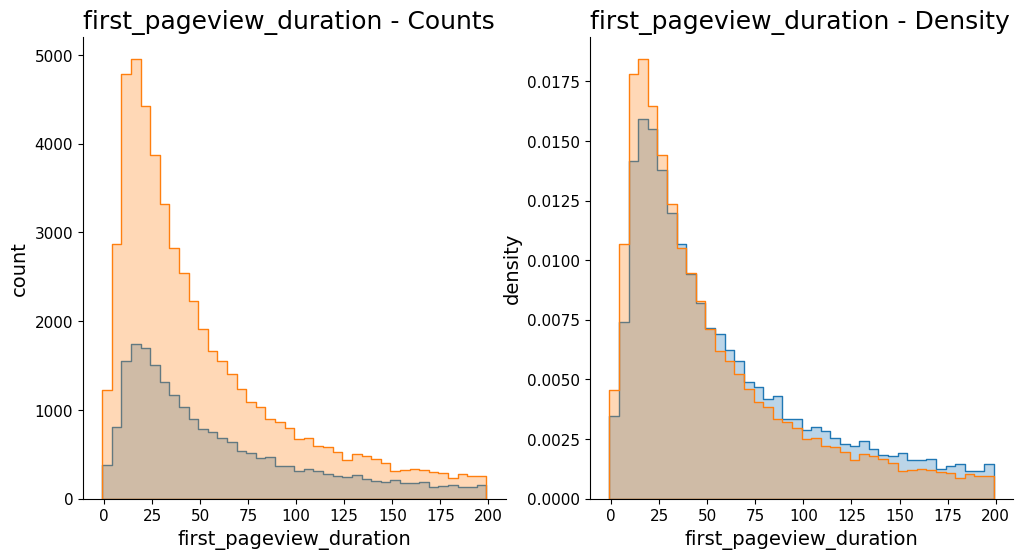

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings('ignore')


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].first_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].first_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'first_pageview_duration - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'first_pageview_duration', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].first_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].first_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'first_pageview_duration - Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'first_pageview_duration', size = 14)
axes[1].set_ylabel('density', size = 14)


In [769]:
said_df[['first_pageview_duration_isnan', 'is_callcenter']].value_counts()

first_pageview_duration_isnan  is_callcenter
False                          0                63952
                               1                29922
True                           1                 7177
                               0                 3544
Name: count, dtype: int64

Text(0, 0.5, 'density')

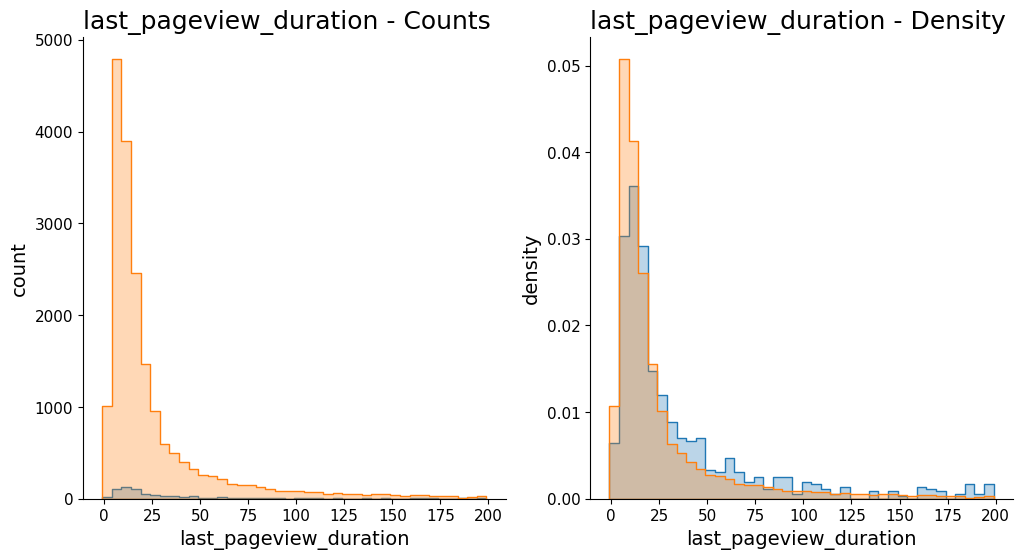

In [ ]:
f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].last_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].last_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'last_pageview_duration - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'last_pageview_duration', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].last_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].last_pageview_duration, alpha=0.3,  bins = np.arange(-1, 200, 5), element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'last_pageview_duration - Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'last_pageview_duration', size = 14)
axes[1].set_ylabel('density', size = 14)


# точно должен быть

In [770]:
said_df[['last_pageview_duration_isnan', 'is_callcenter']].value_counts()

last_pageview_duration_isnan  is_callcenter
False                         0                47866
                              1                36285
True                          0                19630
                              1                  814
Name: count, dtype: int64

In [771]:
said_df[['last_pageview_duration_sign', 'is_callcenter']].value_counts()

last_pageview_duration_sign  is_callcenter
False                        0                47943
                             1                36289
True                         0                19553
                             1                  810
Name: count, dtype: int64

In [773]:
(said_df.last_pageview_duration_isnan == said_df.last_pageview_duration_sign).sum(), said_df.shape

(104514, (104595, 63))

In [774]:
said_df = said_df.drop('last_pageview_duration_sign', axis = 1)

Text(0, 0.5, 'density')

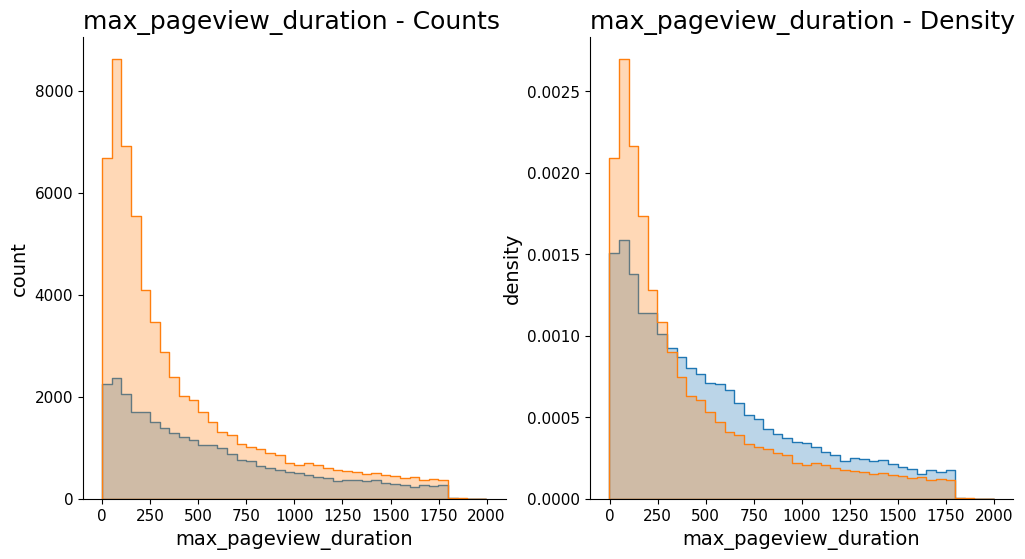

In [ ]:
f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].max_pageview_duration, alpha=0.3,  bins = np.arange(-1, 2000, 50), element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].max_pageview_duration, alpha=0.3,  bins = np.arange(-1, 2000, 50), element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'max_pageview_duration - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'max_pageview_duration', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].max_pageview_duration, alpha=0.3,  bins = np.arange(-1, 2000, 50), element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].max_pageview_duration, alpha=0.3,  bins = np.arange(-1, 2000, 50), element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'max_pageview_duration - Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'max_pageview_duration', size = 14)
axes[1].set_ylabel('density', size = 14)




In [775]:
said_df[['max_pageview_duration_isnan', 'is_callcenter']].value_counts()

max_pageview_duration_isnan  is_callcenter
False                        0                63984
                             1                29930
True                         1                 7169
                             0                 3512
Name: count, dtype: int64

Text(0, 0.5, 'density')

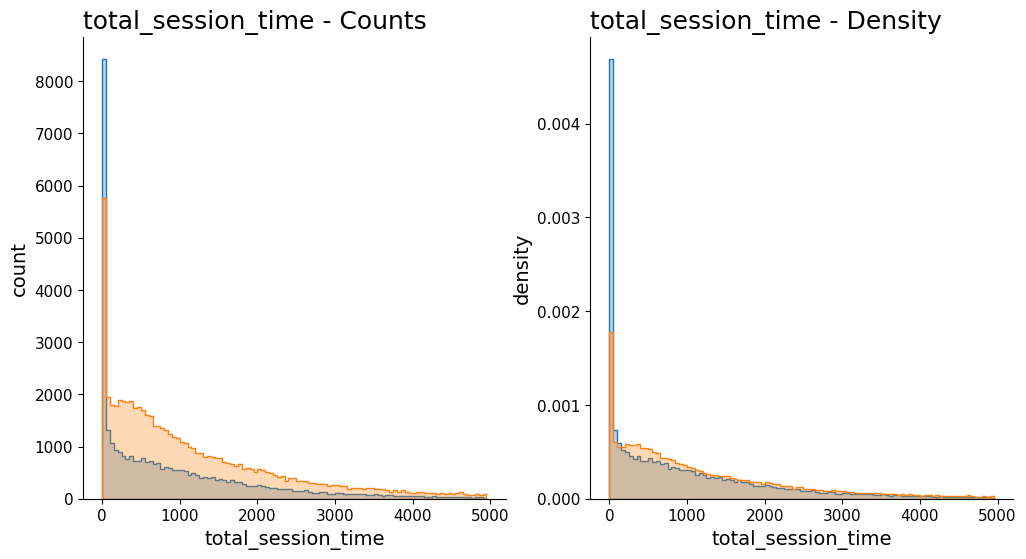

In [ ]:

f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].total_session_time, alpha=0.3,  bins = np.arange(0, 5000, 50), element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_session_time, alpha=0.3,  bins = np.arange(0, 5000, 50), element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'total_session_time - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'total_session_time', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].total_session_time, alpha=0.3,  bins = np.arange(0, 5000, 50), element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_session_time, alpha=0.3,  bins = np.arange(0, 5000, 50), element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'total_session_time - Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'total_session_time', size = 14)
axes[1].set_ylabel('density', size = 14)


# сильный пик на 0!

Text(0, 0.5, 'density')

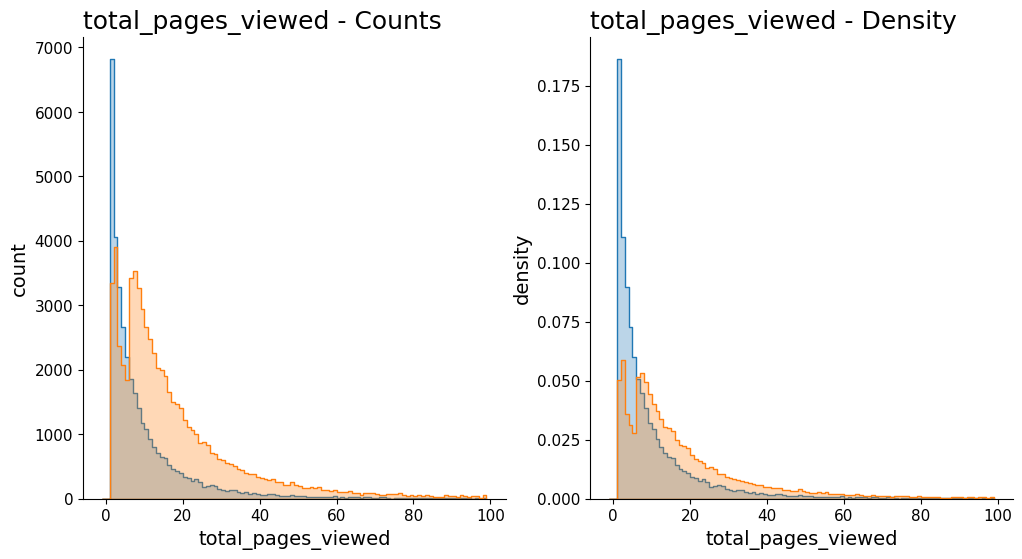

In [ ]:
f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].total_pages_viewed, alpha=0.3,  bins = np.arange(-1, 100, 1), element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_pages_viewed, alpha=0.3,  bins = np.arange(-1, 100, 1), element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'total_pages_viewed - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'total_pages_viewed', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].total_pages_viewed, alpha=0.3,  bins = np.arange(-1, 100, 1), element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_pages_viewed, alpha=0.3,  bins = np.arange(-1, 100, 1), element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'total_pages_viewed - Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'total_pages_viewed', size = 14)
axes[1].set_ylabel('density', size = 14)




Text(0, 0.5, 'density')

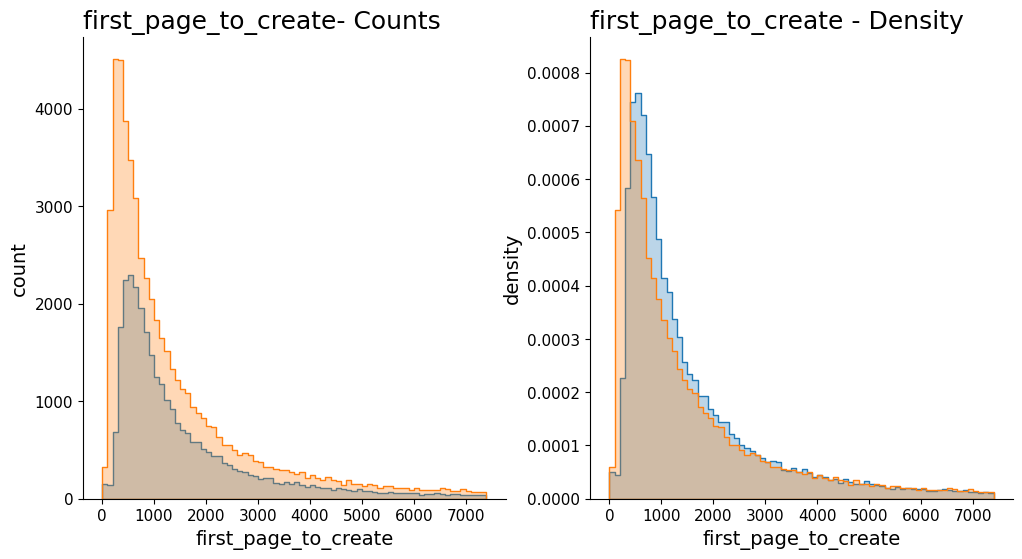

In [ ]:
f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].first_page_to_create_time, bins = np.arange(0, 7500, 100), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].first_page_to_create_time, bins = np.arange(0, 7500, 100),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'first_page_to_create- Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'first_page_to_create', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].first_page_to_create_time, bins = np.arange(0, 7500, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].first_page_to_create_time, bins = np.arange(0, 7500, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'first_page_to_create - Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'first_page_to_create', size = 14)
axes[1].set_ylabel('density', size = 14)

In [777]:
said_df[['first_page_to_create_time_sign', 'is_callcenter']].value_counts()

first_page_to_create_time_sign  is_callcenter
True                            0                67193
                                1                36725
False                           1                  374
                                0                  303
Name: count, dtype: int64

Text(0, 0.5, 'density')

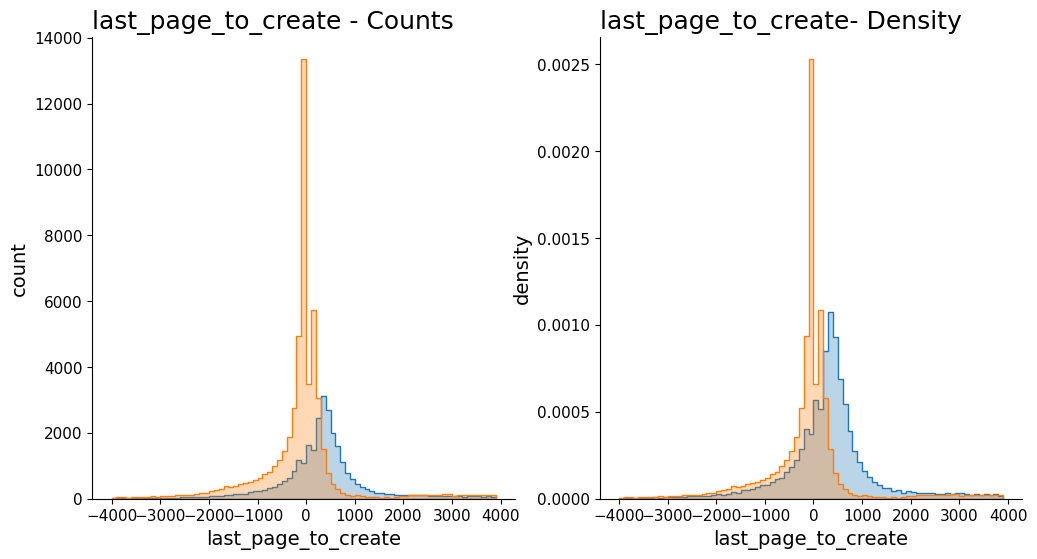

In [ ]:
f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].last_page_to_create_time, bins = np.arange(-4000, 4000, 100), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].last_page_to_create_time, bins = np.arange(-4000, 4000, 100),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'last_page_to_create - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'last_page_to_create', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].last_page_to_create_time, bins = np.arange(-4000, 4000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].last_page_to_create_time, bins = np.arange(-4000, 4000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'last_page_to_create- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'last_page_to_create', size = 14)
axes[1].set_ylabel('density', size = 14)

In [784]:
said_df[['last_page_to_create_time_isnan', 'is_callcenter']].value_counts()

last_page_to_create_time_isnan  is_callcenter
False                           0                47866
                                1                36285
True                            0                19630
                                1                  814
Name: count, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

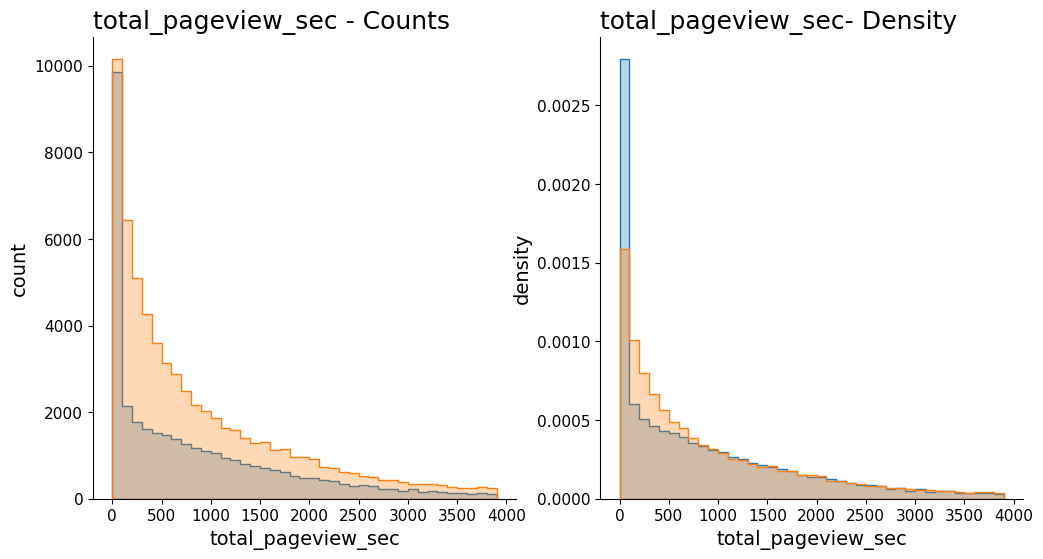

In [785]:
f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].total_pageview_sec, bins = np.arange(0, 4000, 100), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_pageview_sec, bins = np.arange(0, 4000, 100),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'total_pageview_sec - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'total_pageview_sec', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].total_pageview_sec, bins = np.arange(0, 4000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_pageview_sec, bins = np.arange(0, 4000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'total_pageview_sec- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'total_pageview_sec', size = 14)
axes[1].set_ylabel('density', size = 14)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

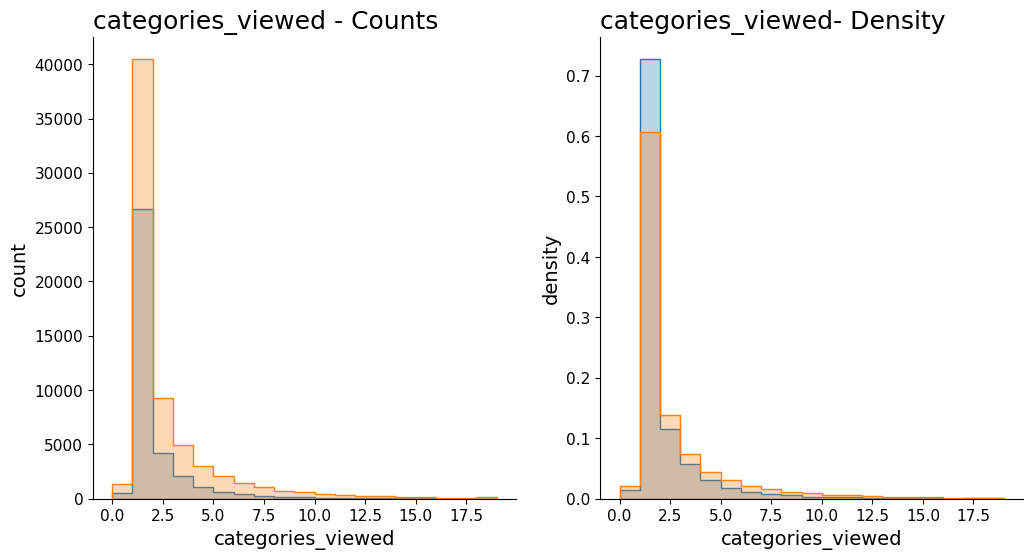

In [ ]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].categories_viewed, bins = np.arange(0, 20, 1), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].categories_viewed, bins = np.arange(0, 20, 1),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'categories_viewed - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'categories_viewed', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].categories_viewed, bins = np.arange(0, 20, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].categories_viewed, bins = np.arange(0, 20, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'categories_viewed- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'categories_viewed', size = 14)
axes[1].set_ylabel('density', size = 14)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

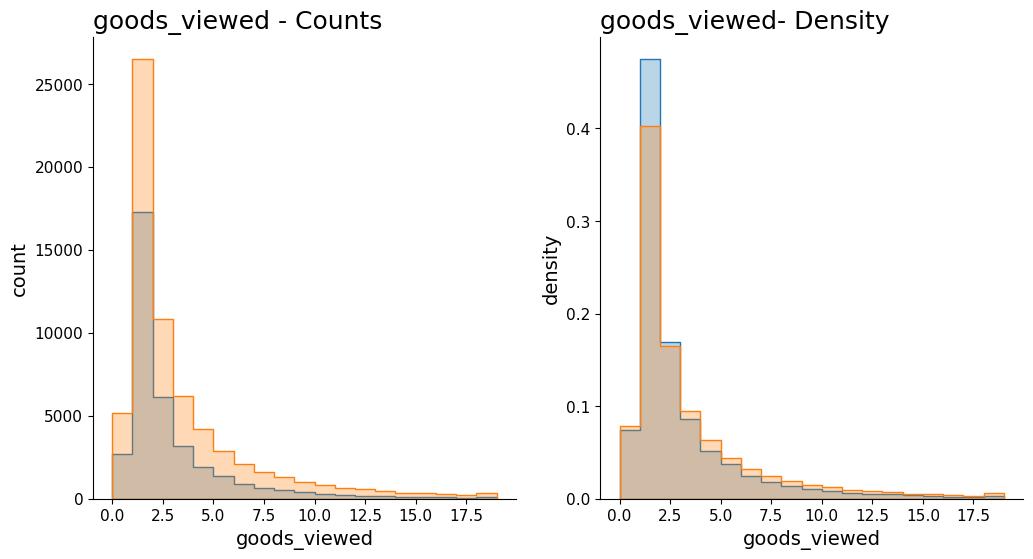

In [ ]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].goods_viewed, bins = np.arange(0, 20, 1), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].goods_viewed, bins = np.arange(0, 20, 1),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'goods_viewed - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'goods_viewed', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].goods_viewed, bins = np.arange(0, 20, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].goods_viewed, bins = np.arange(0, 20, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'goods_viewed- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'goods_viewed', size = 14)
axes[1].set_ylabel('density', size = 14)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

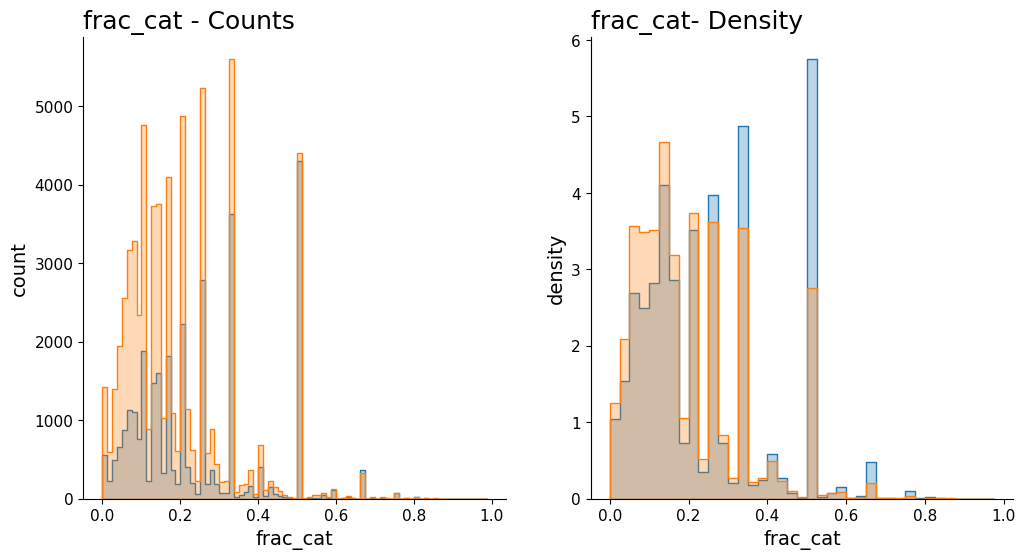

In [790]:
# а если ночью люди не звонят?

f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].frac_cat, bins = np.arange(0, 1, 0.0125), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].frac_cat, bins = np.arange(0, 1, 0.0125),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'frac_cat - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'frac_cat', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].frac_cat, bins = np.arange(0, 1, 0.025),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].frac_cat, bins = np.arange(0, 1, 0.025),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'frac_cat- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'frac_cat', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

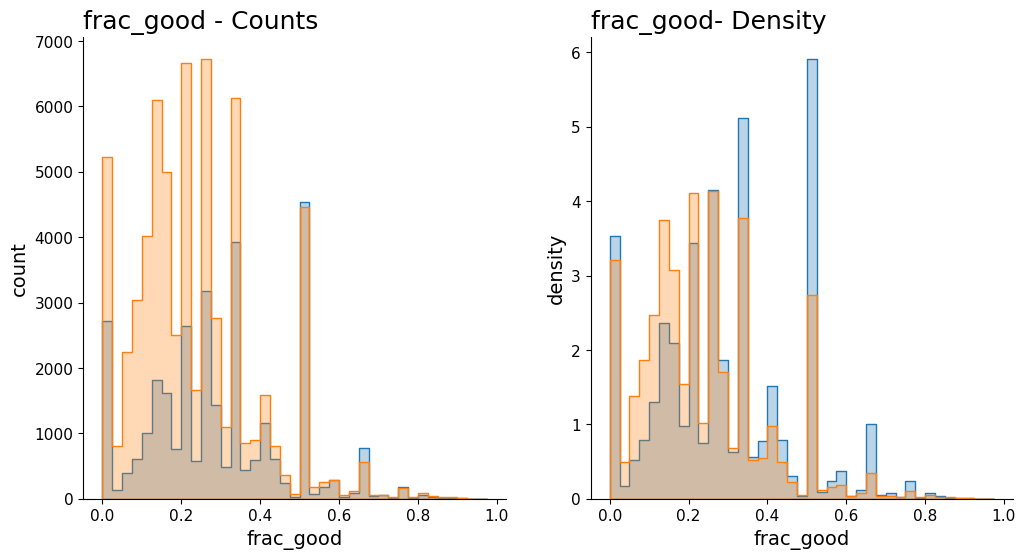

In [ ]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].frac_good, bins = np.arange(0, 1, 0.025), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].frac_good, bins = np.arange(0, 1, 0.025),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'frac_good - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'frac_good', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].frac_good, bins = np.arange(0, 1, 0.025),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].frac_good, bins = np.arange(0, 1, 0.025),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'frac_good- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'frac_good', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

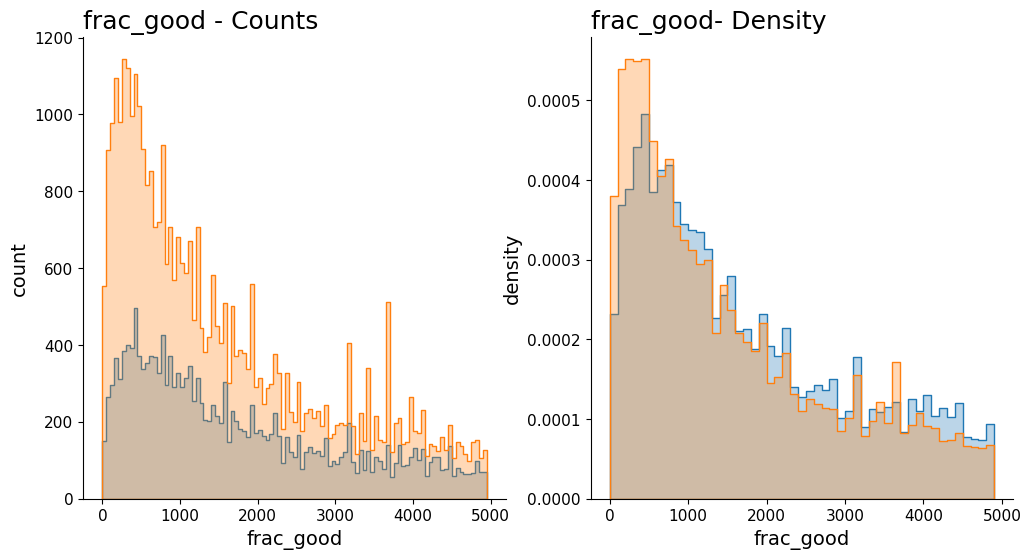

In [792]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].total_price, bins = np.arange(0, 5000, 50), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_price, bins = np.arange(0, 5000, 50),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'frac_good - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'frac_good', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].total_price, bins = np.arange(0, 5000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_price, bins = np.arange(0, 5000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'frac_good- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'frac_good', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

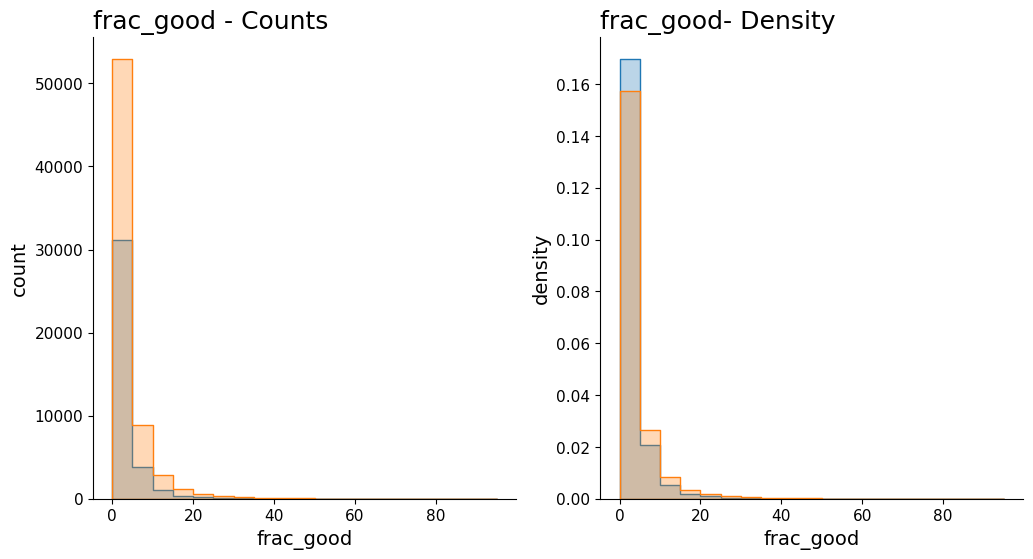

In [794]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].goods_viewed, bins = np.arange(0, 100, 5), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].goods_viewed, bins = np.arange(0, 100, 5),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'frac_good - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'frac_good', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].goods_viewed, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].goods_viewed, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'frac_good- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'frac_good', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

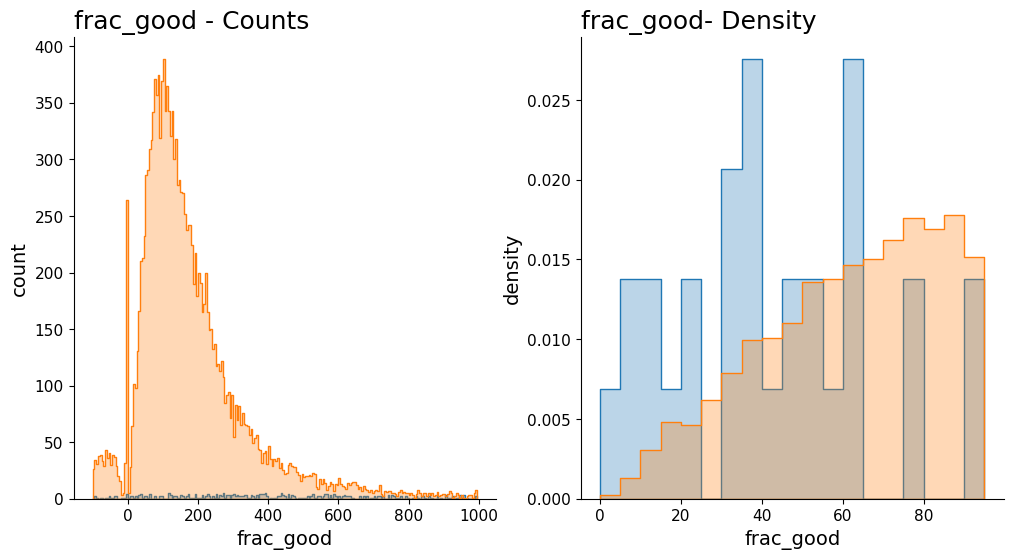

In [797]:

f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].after_last_page, bins = np.arange(-100, 1000, 5), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].after_last_page, bins = np.arange(-100, 1000, 5),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'frac_good - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'frac_good', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].after_last_page, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].after_last_page, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'frac_good- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'frac_good', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

In [799]:
said_df[said_df['is_callcenter'] == 1].after_last_page.value_counts(dropna = False)

after_last_page
 NaN          36285
 865.743          1
-111.830          1
 19085.300        1
-36.050           1
              ...  
 13.537           1
 87514.167        1
 5897.293         1
-118.947          1
 5024.850         1
Name: count, Length: 815, dtype: int64

In [ ]:
36285 / said_df[said_df['is_callcenter'] == 1].shape[0]    # почти все которые звонили есть NAN вот тут

0.9780587077818809

In [ ]:
said_df[said_df['is_callcenter'] == 0].after_last_page.value_counts(dropna = False)

after_last_page
 NaN        47866
 110.983        4
 75.317         3
 271.550        3
 145.580        3
            ...  
 104.783        1
 368.223        1
 338.897        1
 131.533        1
-59.047         1
Name: count, Length: 18651, dtype: int64

In [ ]:
47866 / said_df[said_df['is_callcenter'] == 0].shape[0]          # большая часть тоже с NAN

0.7091679506933745

In [804]:
said_df[said_df['after_last_page'].isna()].is_callcenter.value_counts()

is_callcenter
0    47866
1    36285
Name: count, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

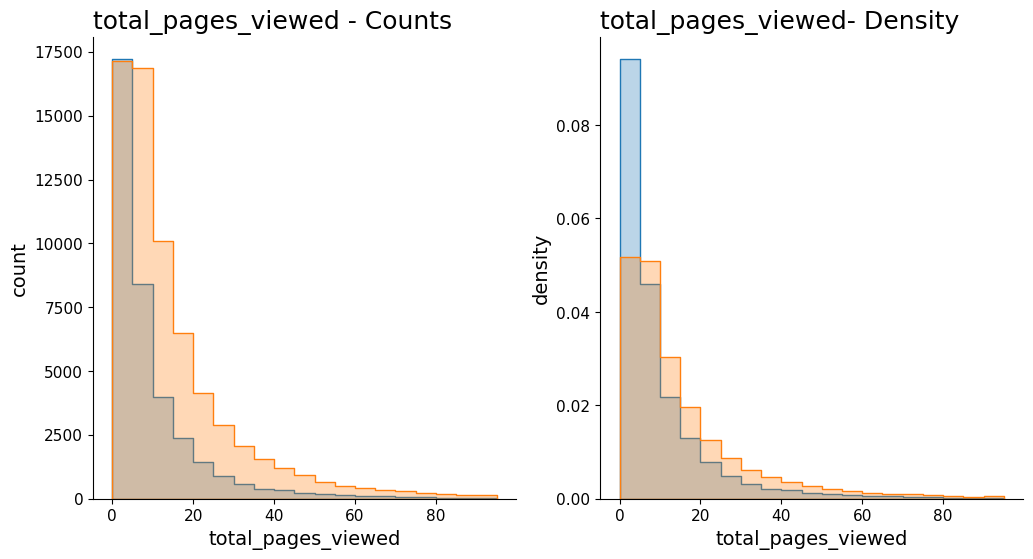

In [811]:

f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].total_pages_viewed, bins = np.arange(0, 100, 5), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_pages_viewed, bins = np.arange(0, 100, 5),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'total_pages_viewed - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'total_pages_viewed', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].total_pages_viewed, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].total_pages_viewed, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'total_pages_viewed- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'total_pages_viewed', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

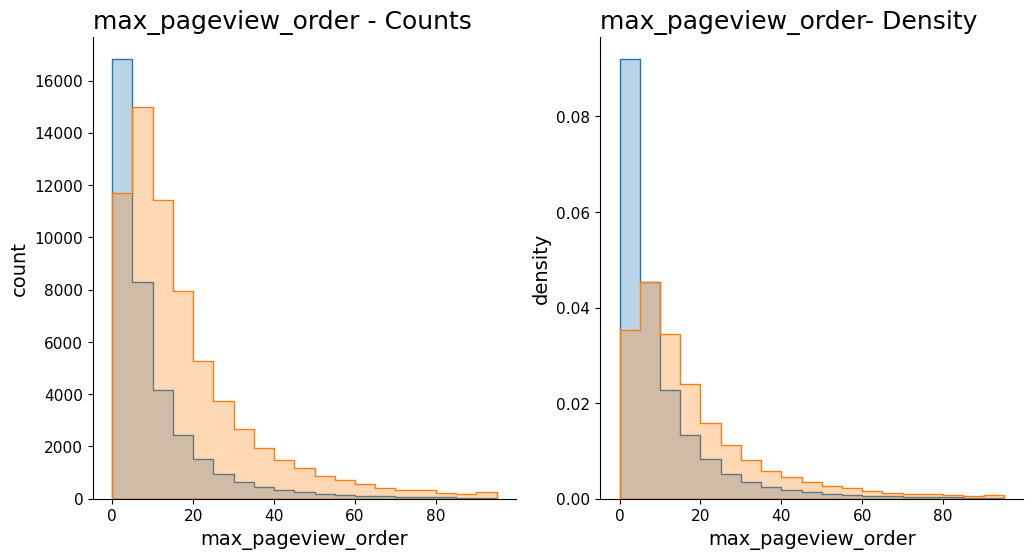

In [812]:

f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].max_pageview_order, bins = np.arange(0, 100, 5), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].max_pageview_order, bins = np.arange(0, 100, 5),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'max_pageview_order - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'max_pageview_order', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].max_pageview_order, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].max_pageview_order, bins = np.arange(0, 100, 5),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'max_pageview_order- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'max_pageview_order', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

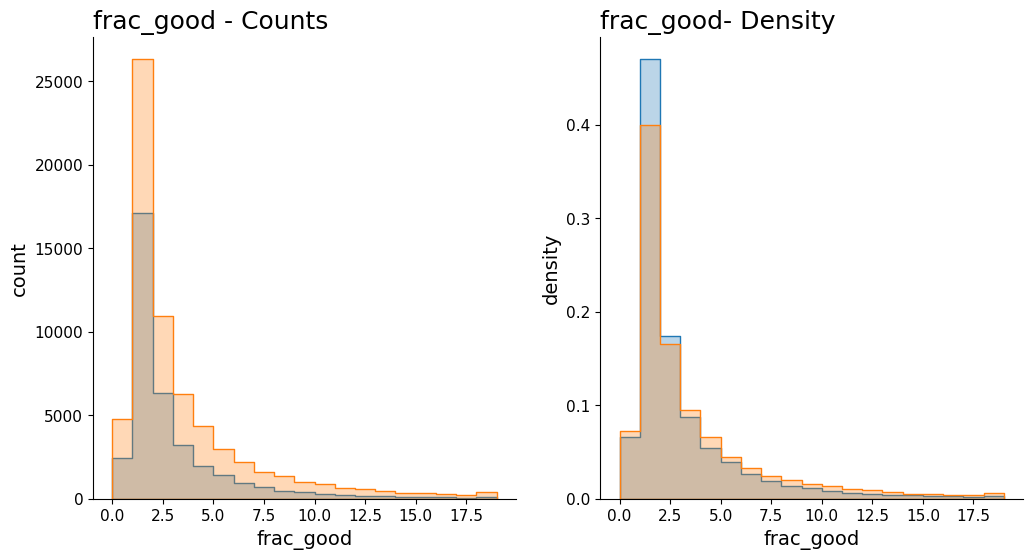

In [807]:

f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].model_id_num, bins = np.arange(0, 20, 1), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].model_id_num, bins = np.arange(0, 20, 1),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'frac_good - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'frac_good', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].model_id_num, bins = np.arange(0, 20, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].model_id_num, bins = np.arange(0, 20, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'frac_good- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'frac_good', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

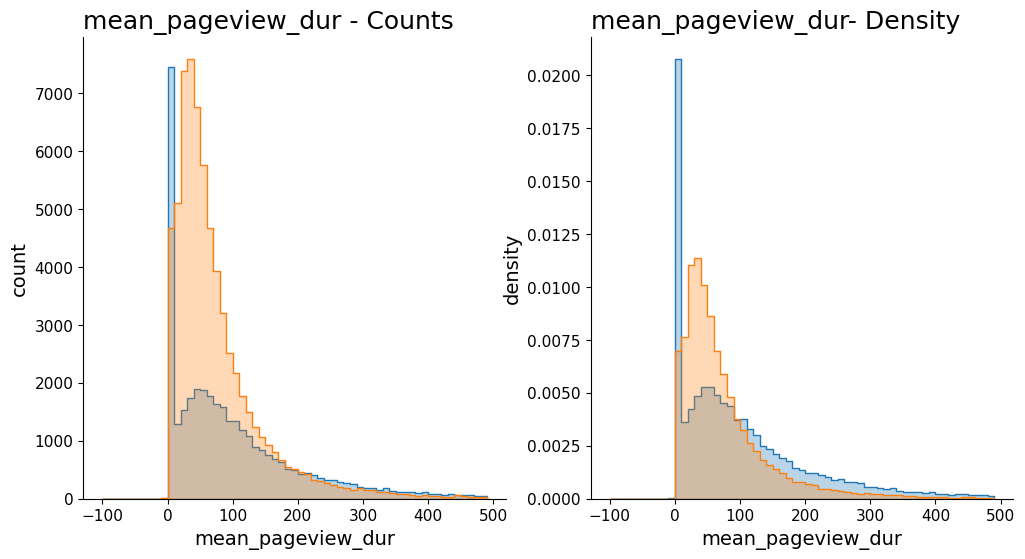

In [809]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].mean_pageview_dur, bins = np.arange(-100, 500, 10), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].mean_pageview_dur, bins = np.arange(-100, 500, 10),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'mean_pageview_dur - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'mean_pageview_dur', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].mean_pageview_dur, bins = np.arange(-100, 500, 10),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].mean_pageview_dur, bins = np.arange(-100, 500, 10),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'mean_pageview_dur- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'mean_pageview_dur', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

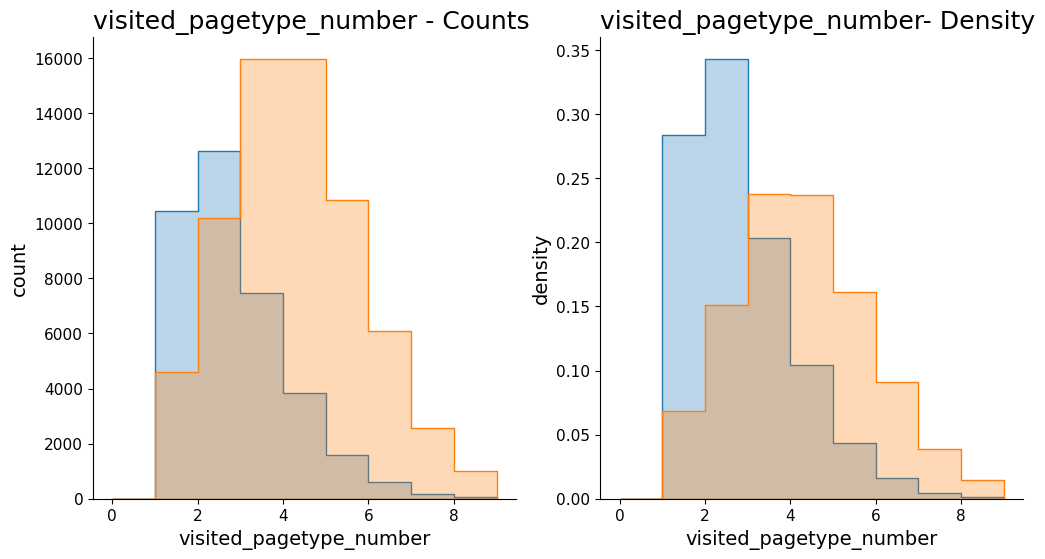

In [813]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].visited_pagetype_number, bins = np.arange(0, 10, 1), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].visited_pagetype_number, bins = np.arange(0, 10, 1),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'visited_pagetype_number - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'visited_pagetype_number', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].visited_pagetype_number, bins = np.arange(0, 10, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].visited_pagetype_number, bins = np.arange(0, 10, 1),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'visited_pagetype_number- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'visited_pagetype_number', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

### тут основыне идеи / выводы из новых фичей

Посмотрим на время между созданием заказа и временем захода на последнюю страницу сессии.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'density')

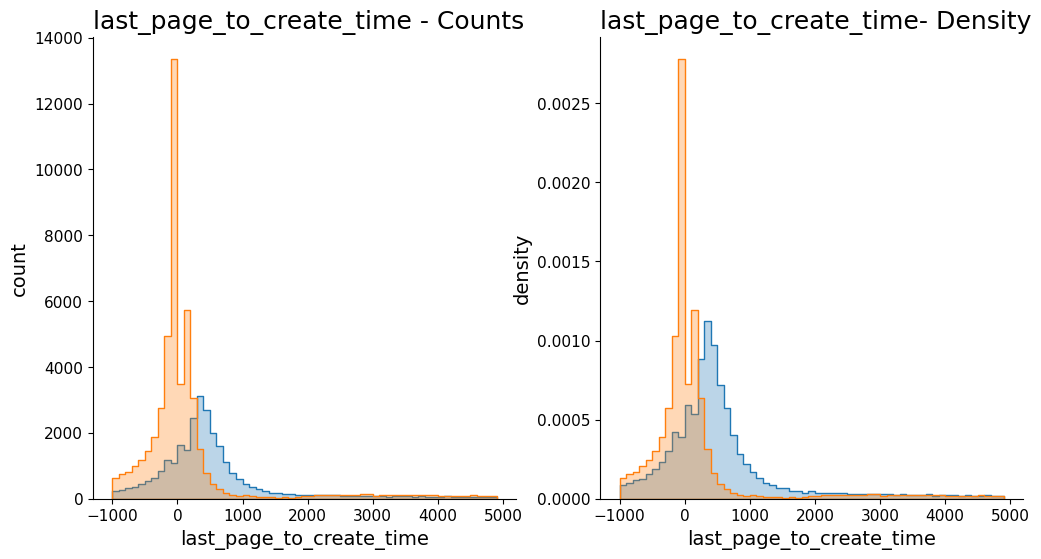

In [ ]:


f, axes = plt.subplots(1, 2, figsize = (12, 6))


sns.histplot(said_df[(said_df.is_callcenter == 1)].last_page_to_create_time, bins = np.arange(-1000, 5000, 100), alpha=0.3,  element="step", ax = axes[0])
sns.histplot(said_df[(said_df.is_callcenter == 0)].last_page_to_create_time, bins = np.arange(-1000, 5000, 100),alpha=0.3,  element="step", ax = axes[0])
sns.despine()
axes[0].set_title(f'last_page_to_create_time - Counts', fontsize=18, loc = 'left')
axes[0].tick_params(axis='both', labelsize=11)
axes[0].legend(fontsize=15)
axes[0].get_legend().remove()
axes[0].set_xlabel(f'last_page_to_create_time', size = 14)
axes[0].set_ylabel('count', size = 14)

sns.histplot(said_df[(said_df.is_callcenter == 1)].last_page_to_create_time, bins = np.arange(-1000, 5000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.histplot(said_df[(said_df.is_callcenter == 0)].last_page_to_create_time, bins = np.arange(-1000, 5000, 100),alpha=0.3, element="step", stat = 'density', ax = axes[1])
sns.despine()
axes[1].set_title(f'last_page_to_create_time- Density', fontsize=18, loc = 'left')
axes[1].tick_params(axis='both', labelsize=11)
axes[1].legend(fontsize=15)
axes[1].get_legend().remove()
axes[1].set_xlabel(f'last_page_to_create_time', size = 14)
axes[1].set_ylabel('density', size = 14)


# есьт потенциал (слишком низкий хзвахва)

Видим хорошее разделение: Для значений между 300 и 1800 люди в основном звонят, для остальных - нет

НО: здесь нет еще одного важного значения этой переменной, а именно NAN

In [781]:
said_df[['last_page_to_create_time_isnan', 'is_callcenter']].value_counts()

last_page_to_create_time_isnan  is_callcenter
False                           0                47866
                                1                36285
True                            0                19630
                                1                  814
Name: count, dtype: int64

Практически все, у кого last_pageview_duration_isnan имеет значение True, НЕ звонят нам) 

Поэтому: мы знаем, что отлично умеем предсказывать (да даже const предсазанеи одного класса даст норм качество) - для NaN и промежутка 300-1800 фичи `last_page_to_create_time`
Оставшиеся промежутки я разделила на <300 (вместе с отрицталеьными значениями), а также >1800.

In [818]:
manual_df = said_df

In [ ]:
# и добавляю еще фичи, в которых наблюадется дисбаланс классов

manual_df['after_last_page_isnan'] = manual_df['after_last_page'].isna()
manual_df['last_page_to_create_time_isneg'] = manual_df['last_page_to_create_time'] < 0
manual_df['max_pageview_order_is1'] = manual_df['max_pageview_order'] == 1
manual_df['mean_pageview_dur_is0'] = manual_df['mean_pageview_dur'] == 0
manual_df['total_pages_viewed_is1'] = manual_df['total_pages_viewed'] == 1
manual_df['visited_pagetype_number_is1'] = manual_df['visited_pagetype_number'] == 1


In [ ]:
manual_df = manual_df.drop(['model_create_time', 'last_page_time', 'last_page_time', 'create_time'], axis = 1)

In [885]:
# fit different data

prep1 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep2 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep3 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep4 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

X, y = sss.drop('is_callcenter', axis = 1), sss.is_callcenter
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size= 0.05)

idx1 = X_train[(X_train['last_page_to_create_time'] <= 1800) & (X_train['last_page_to_create_time'] >= 300)].index
idx2 = X_train[X_train['last_page_to_create_time'] > 1800].index
idx3 = X_train[X_train['last_page_to_create_time'] < 300].index
idx4 = X_train[X_train['last_page_to_create_time'].isna()].index

X1, y1 = X_train.loc[idx1, :], y_train[idx1]
X2, y2 = X_train.loc[idx2, :], y_train[idx2]
X3, y3 = X_train.loc[idx3, :], y_train[idx3]
X4, y4 = X_train.loc[idx4, :], y_train[idx4]

X1 = prep1.fit_transform(X1)
X2 = prep2.fit_transform(X2)
X3 = prep3.fit_transform(X3)
X4 = prep4.fit_transform(X4)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

idx1_test = X_test[(X_test['last_page_to_create_time'] <= 1800) & (X_test['last_page_to_create_time'] >= 300)].index
idx2_test = X_test[X_test['last_page_to_create_time'] > 1800].index
idx3_test = X_test[X_test['last_page_to_create_time'] < 300].index
idx4_test = X_test[X_test['last_page_to_create_time'].isna()].index


X1_test, y1_test = X_test.loc[idx1_test, :], y_test[idx1_test]
X2_test, y2_test = X_test.loc[idx2_test, :], y_test[idx2_test]
X3_test, y3_test = X_test.loc[idx3_test, :], y_test[idx3_test]
X4_test, y4_test = X_test.loc[idx4_test, :], y_test[idx4_test]

X1_test = prep1.transform(X1_test)
X2_test = prep2.transform(X2_test)
X3_test = prep3.transform(X3_test)
X4_test = prep4.transform(X4_test)

clf1 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf1.fit(X1, y1)
print(f'interclass 1 (300 <= x <= 1800)) rocauc = {roc_auc_score(y1_test, clf1.predict_proba(X1_test)[:,1])}')


clf2 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf2.fit(X2, y2)
print(f'interclass 2 (>1800) rocauc = {roc_auc_score(y2_test, clf2.predict_proba(X2_test)[:,1])}')

clf3 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf3.fit(X3, y3)
print(f'interclass 3 (<300) rocauc = {roc_auc_score(y3_test, clf3.predict_proba(X3_test)[:,1])}')

clf4 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf4.fit(X4, y4)
print(f'interclass 4 isnan rocauc = {roc_auc_score(y4_test, clf4.predict_proba(X4_test)[:,1])}')


out_y = np.zeros(y_test.shape)
out_y[idx1_test] = clf1.predict_proba(X1_test)[:,1]
out_y[idx2_test] = clf2.predict_proba(X2_test)[:,1]
out_y[idx3_test] = clf3.predict_proba(X3_test)[:,1]
out_y[idx4_test] = clf4.predict_proba(X4_test)[:,1]

full_rocauc = roc_auc_score(y_test, out_y)
print('full selected features rocauc: ', full_rocauc)

interclass 1 (300 <= x <= 1800)) rocauc = 0.985283681835406
interclass 2 (>1800) rocauc = 0.6327795158399903
interclass 3 (<300) rocauc = 0.9814848055197847
interclass 4 isnan rocauc = 0.3159722222222222
full selected features rocauc:  0.9597432343306861


In [ ]:
# fit different data
prep1 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep2 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep3 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep4 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

X, y = manual_df.drop('is_callcenter', axis = 1), manual_df.is_callcenter
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size= 0.05)

idx1 = X_train[(X_train['last_page_to_create_time'] <= 1800) & (X_train['last_page_to_create_time'] >= 300)].index
idx2 = X_train[X_train['last_page_to_create_time'] > 1800].index
idx3 = X_train[X_train['last_page_to_create_time'] < 300].index
idx4 = X_train[X_train['last_page_to_create_time'].isna()].index

X1, y1 = X_train.loc[idx1, :], y_train[idx1]
X2, y2 = X_train.loc[idx2, :], y_train[idx2]
X3, y3 = X_train.loc[idx3, :], y_train[idx3]
X4, y4 = X_train.loc[idx4, :], y_train[idx4]

X1 = prep1.fit_transform(X1)
X2 = prep2.fit_transform(X2)
X3 = prep3.fit_transform(X3)
X4 = prep4.fit_transform(X4)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

idx1_test = X_test[(X_test['last_page_to_create_time'] <= 1800) & (X_test['last_page_to_create_time'] >= 300)].index
idx2_test = X_test[X_test['last_page_to_create_time'] > 1800].index
idx3_test = X_test[X_test['last_page_to_create_time'] < 300].index
idx4_test = X_test[X_test['last_page_to_create_time'].isna()].index


X1_test, y1_test = X_test.loc[idx1_test, :], y_test[idx1_test]
X2_test, y2_test = X_test.loc[idx2_test, :], y_test[idx2_test]
X3_test, y3_test = X_test.loc[idx3_test, :], y_test[idx3_test]
X4_test, y4_test = X_test.loc[idx4_test, :], y_test[idx4_test]

X1_test = prep1.transform(X1_test)
X2_test = prep2.transform(X2_test)
X3_test = prep3.transform(X3_test)
X4_test = prep4.transform(X4_test)

clf1 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf1.fit(X1, y1)
rocauc1 = roc_auc_score(y1_test, clf1.predict_proba(X1_test)[:,1])
print(f'interclass 1 (300 <= x <= 1800)) rocauc = {roc_auc_score(y1_test, clf1.predict_proba(X1_test)[:,1])}')


clf2 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf2.fit(X2, y2)
rocauc2 = roc_auc_score(y2_test, clf2.predict_proba(X2_test)[:,1])
print(f'interclass 2 (>1800) rocauc = {roc_auc_score(y2_test, clf2.predict_proba(X2_test)[:,1])}')

clf3 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf3.fit(X3, y3)
rocauc3 = roc_auc_score(y3_test, clf3.predict_proba(X3_test)[:,1])
print(f'interclass 3 (<300) rocauc = {roc_auc_score(y3_test, clf3.predict_proba(X3_test)[:,1])}')

clf4 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf4.fit(X4, y4)
rocauc4 = roc_auc_score(y4_test, clf4.predict_proba(X4_test)[:,1])
print(f'interclass 4 isnan rocauc = {roc_auc_score(y4_test, clf4.predict_proba(X4_test)[:,1])}')


out_y = np.zeros(y_test.shape)
out_y[idx1_test] = clf1.predict_proba(X1_test)[:,1]
out_y[idx2_test] = clf2.predict_proba(X2_test)[:,1]
out_y[idx3_test] = clf3.predict_proba(X3_test)[:,1]
out_y[idx4_test] = clf4.predict_proba(X4_test)[:,1]

full_rocauc = roc_auc_score(y_test, out_y)
print('full selected features rocauc: ', full_rocauc)


interclass 1 (300 <= x <= 1800)) rocauc = 0.9849185297461159
interclass 2 (>1800) rocauc = 0.6484441658635991
interclass 3 (<300) rocauc = 0.981759368767211
interclass 4 isnan rocauc = 0.5694444444444445
full selected features rocauc:  0.9607813438437542


Вот такое качество получилось на ВСЕХ данных. Удаление признаков из `train.csv` ситуацию не улучшает, поэтому сдаю как есть

In [895]:
# fit different data
prep1 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep2 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep3 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep4 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

X, y = manual_df.drop('is_callcenter', axis = 1), manual_df.is_callcenter
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size= 0.05)

idx1 = X_train[(X_train['last_page_to_create_time'] <= 1800) & (X_train['last_page_to_create_time'] >= 300)].index
idx2 = X_train[X_train['last_page_to_create_time'] > 1800].index
idx3 = X_train[X_train['last_page_to_create_time'] < 300].index
idx4 = X_train[X_train['last_page_to_create_time'].isna()].index

X1, y1 = X_train.loc[idx1, :], y_train[idx1]
X2, y2 = X_train.loc[idx2, :], y_train[idx2]
X3, y3 = X_train.loc[idx3, :], y_train[idx3]
X4, y4 = X_train.loc[idx4, :], y_train[idx4]

X1 = prep1.fit_transform(X1)
X2 = prep2.fit_transform(X2)
X3 = prep3.fit_transform(X3)
X4 = prep4.fit_transform(X4)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

idx1_test = X_test[(X_test['last_page_to_create_time'] <= 1800) & (X_test['last_page_to_create_time'] >= 300)].index
idx2_test = X_test[X_test['last_page_to_create_time'] > 1800].index
idx3_test = X_test[X_test['last_page_to_create_time'] < 300].index
idx4_test = X_test[X_test['last_page_to_create_time'].isna()].index


X1_test, y1_test = X_test.loc[idx1_test, :], y_test[idx1_test]
X2_test, y2_test = X_test.loc[idx2_test, :], y_test[idx2_test]
X3_test, y3_test = X_test.loc[idx3_test, :], y_test[idx3_test]
X4_test, y4_test = X_test.loc[idx4_test, :], y_test[idx4_test]

X1_test = prep1.transform(X1_test)
X2_test = prep2.transform(X2_test)
X3_test = prep3.transform(X3_test)
X4_test = prep4.transform(X4_test)

clf1 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf1.fit(X1, y1)
rocauc1 = roc_auc_score(y1_test, clf1.predict_proba(X1_test)[:,1])
print(f'interclass 1 (300 <= x <= 1800)) rocauc = {roc_auc_score(y1_test, clf1.predict_proba(X1_test)[:,1])}')


clf2 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf2.fit(X2, y2)
rocauc2 = roc_auc_score(y2_test, clf2.predict_proba(X2_test)[:,1])
print(f'interclass 2 (>1800) rocauc = {roc_auc_score(y2_test, clf2.predict_proba(X2_test)[:,1])}')

clf3 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf3.fit(X3, y3)
rocauc3 = roc_auc_score(y3_test, clf3.predict_proba(X3_test)[:,1])
print(f'interclass 3 (<300) rocauc = {roc_auc_score(y3_test, clf3.predict_proba(X3_test)[:,1])}')

clf4 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf4.fit(X4, y4)
rocauc4 = roc_auc_score(y4_test, clf4.predict_proba(X4_test)[:,1])
print(f'interclass 4 isnan rocauc = {roc_auc_score(y4_test, clf4.predict_proba(X4_test)[:,1])}')


out_y = np.zeros(y_test.shape)
out_y[idx1_test] = clf1.predict_proba(X1_test)[:,1]
out_y[idx2_test] = clf2.predict_proba(X2_test)[:,1]
out_y[idx3_test] = clf3.predict_proba(X3_test)[:,1]
out_y[idx4_test] = clf4.predict_proba(X4_test)[:,1]

full_rocauc = roc_auc_score(y_test, out_y)
print('full selected features rocauc: ', full_rocauc)


interclass 1 (300 <= x <= 1800)) rocauc = 0.9849185297461159
interclass 2 (>1800) rocauc = 0.6484441658635991
interclass 3 (<300) rocauc = 0.981759368767211
interclass 4 isnan rocauc = 0.5694444444444445
full selected features rocauc:  0.9607813438437542


### create submission

обучила на всех данных и сдала. получила 0.95 на паблике

In [908]:
# fit different data
prep1 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep2 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep3 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

prep4 = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

X, y = manual_df.drop('is_callcenter', axis = 1), manual_df.is_callcenter
X_train, y_train = X, y

idx1 = X_train[(X_train['last_page_to_create_time'] <= 1800) & (X_train['last_page_to_create_time'] >= 300)].index
idx2 = X_train[X_train['last_page_to_create_time'] > 1800].index
idx3 = X_train[X_train['last_page_to_create_time'] < 300].index
idx4 = X_train[X_train['last_page_to_create_time'].isna()].index

X1, y1 = X_train.loc[idx1, :], y_train[idx1]
X2, y2 = X_train.loc[idx2, :], y_train[idx2]
X3, y3 = X_train.loc[idx3, :], y_train[idx3]
X4, y4 = X_train.loc[idx4, :], y_train[idx4]

X1 = prep1.fit_transform(X1)
X2 = prep2.fit_transform(X2)
X3 = prep3.fit_transform(X3)
X4 = prep4.fit_transform(X4)



clf1 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf1.fit(X1, y1)


clf2 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf2.fit(X2, y2)

clf3 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf3.fit(X3, y3)

clf4 = LogisticRegression(random_state = 42, solver = 'liblinear')
clf4.fit(X4, y4)



LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
manual_df.columns

In [909]:
# last solution (hopefully)

test_df = pd.read_csv('/Users/macbook/Desktop/test.csv')

test_df = test_df.merge(sessions_agg, on = 'sessionkey_id', how = 'left', validate = 'm:m')


In [910]:
test_df['create_time'] = pd.to_datetime(test_df['create_time'])

test_df['searched_good'] = [str(float(test_df['good_id'][i])) in test_df['good_ids'][i].split() if type(test_df['good_ids'][i]) == str else np.nan for i in range(test_df.shape[0])]

test_df = test_df.drop('good_ids', axis = 1)

test_df['max_pageview_duration_isnan'] = test_df['max_pageview_duration'].isna()
test_df['last_pageview_duration_isnan'] = -test_df['last_pageview_duration'].isna()


test_df['first_pageview_duration_isnan'] = test_df['max_pageview_duration'].isna()

test_df['first_page_to_create_time'] = (test_df['create_time'] - test_df['first_page_time']).dt.total_seconds()
test_df['last_page_to_create_time'] = (test_df['create_time'] - test_df['last_page_time']).dt.total_seconds()


test_df['first_page_to_create_time_sign'] = test_df['first_page_to_create_time'] > 0
test_df['last_pageview_duration_sign'] = test_df['last_pageview_duration'] > 0

test_df['after_last_page'] = test_df['last_page_to_create_time'] - test_df['last_pageview_duration']

test_df['total_price'] = test_df.price * test_df.goods_qty

test_df['create_weekday'] = test_df.create_time.dt.weekday

test_df['date_to_center'] = (test_df['create_time'] - test_df.create_time.mean()).dt.total_seconds()
test_df['date_to_center'] = test_df['date_to_center'] / 1000
test_df['date_to_center']


test_df['after_last_page_isnan'] = test_df['after_last_page'].isna()
test_df['last_page_to_create_time_isneg'] = test_df['last_page_to_create_time'] < 0
test_df['last_page_to_create_time_isnan'] = test_df['last_page_to_create_time'] < 0
test_df['max_pageview_order_is1'] = test_df['max_pageview_order'] == 1
test_df['mean_pageview_dur_is0'] = test_df['mean_pageview_dur'] == 0
test_df['total_pages_viewed_is1'] = test_df['total_pages_viewed'] == 1
test_df['visited_pagetype_number_is1'] = test_df['visited_pagetype_number'] == 1
test_df['month'] = test_df['create_time'].dt.month

test_df['last_page_to_create_time_isnan'] = test_df['first_pageview_duration_isnan']


test_df['utm_medium_is_6'] = test_df['utm_medium'] == 6
test_df['utm_medium_is_8'] = test_df['utm_medium'] == 8

In [911]:
for col in manual_df.drop('is_callcenter', axis = 1).columns:
    if col not in test_df.columns:
        print(col)

In [912]:
r = test_df[manual_df.drop('is_callcenter', axis = 1).columns]

In [913]:
# fit different data
idx1_test = r[(r['last_page_to_create_time'] <= 1800) & (r['last_page_to_create_time'] >= 300)].index
idx2_test = r[r['last_page_to_create_time'] > 1800].index
idx3_test = r[r['last_page_to_create_time'] < 300].index
idx4_test = r[r['last_page_to_create_time'].isna()].index


X1_test = r.loc[idx1_test, :]
X2_test = r.loc[idx2_test, :]
X3_test = r.loc[idx3_test, :]
X4_test = r.loc[idx4_test, :]

X1_test = prep1.transform(X1_test)
X2_test = prep2.transform(X2_test)
X3_test = prep3.transform(X3_test)
X4_test = prep4.transform(X4_test)

y_pred_test = np.zeros(r.shape[0])
y_pred_test[idx1_test] = clf1.predict_proba(X1_test)[:,1]
y_pred_test[idx2_test] = clf2.predict_proba(X2_test)[:,1]
y_pred_test[idx3_test] = clf3.predict_proba(X3_test)[:,1]
y_pred_test[idx4_test] = clf4.predict_proba(X4_test)[:,1]

assert r.shape[0] == y_pred_test.shape[0]
y_pred_test


array([0.12946071, 0.01015863, 0.5023446 , ..., 0.98986173, 0.14161531,
       0.378298  ])

In [ ]:

output = pd.DataFrame(data = None)
output['is_callcenter'] = y_pred_test
output['order_id'] = test_df['order_id']

output.to_csv('/Users/macbook/Desktop/solution.csv', index = False)

submission

### 3 веселые фичи

Здесь решение на 0.88 на всего трех фичах - логичное, без мусорное, красивое...

In [ ]:
# !!!!!!!!!! my answer number 1

np.random.seed(42)

prep = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

zhopa = manual_df[['visited_6_pagetype', 'visited_3_pagetype', 'last_page_to_create', 'is_callcenter']]


X, y = zhopa.drop(['is_callcenter'], axis = 1), zhopa.is_callcenter
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.2)

X_train = prep.fit_transform(X_train)
X_test = prep.transform(X_test)


clf = LogisticRegression(random_state = 42, solver = 'liblinear')
clf.fit(X_train, y_train)
full_rocauc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
print('full selected features rocauc: ', full_rocauc)

full selected features rocauc:  0.8761635133599793


## что не выстрелило

Мне кажется, что большая часть моих фичей бесполезны и мусорны, а еще нелогичны от слова совсем.

НО отбор по логике не приводил ни к чему хорошему - максимум 0.92, поэтому для побития порога я использовала все фичи всех датасетов :(  